# 01: Data Ingestion

**Project:** Multi-Disease Outbreak Forecasting with Temporal Deep Learning
**Research Question:** Can we accurately forecast short-term disease incidence (4–8 weeks ahead) across Canadian provinces using historical weekly case counts, and does a deep learning approach (LSTM or Transformer-based) outperform classical baselines such as ARIMA or Prophet?
**End User:** Provincial and federal public health agencies (e.g., PHAC), epidemiologists, health system planners.

This notebook does several things:
1. It downloads the normalized CANDID dataset from the IIDDA REST API, caches it locally, and performs an initial inspection of its structure using three diseases.
2. It downloads the PHAC dataset for those three diseases as a cross validation against our CANDID dataset (PHAC data is annual, while CANDID is weekly).
3. After data cross validation, we make a decision on go forward with data and proceed with EDA.

Note: the data folders are in the `.gitignore` because of the sheer size of the raw CSV. Each team member should run this notebook once to cache the file locally.

**Primary Dataset:** `canmod-cdi-normalized` — Canadian Harmonized and Normalized Communicable Disease Incidence Data  
**API:** https://math.mcmaster.ca/iidda/api/  
**Paper:** Earn et al. (2024), *PLOS Global Public Health*


**Secondary Dataset:** `phac-data` - Public Health Agency of Canada Large Data Extract
**URL:** Notifiable Disease Dataset Extraction: https://diseases.canada.ca/notifiable/extract-dataset

In [33]:
# Colab setup
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

drive.mount("/content/drive", force_remount=False)

# Group folder
REPO_DIR = "/content/drive/MyDrive/AAI-590-Capstone-Project"

RAW_DIR = os.path.join(REPO_DIR, "data", "raw")
PROC_DIR = os.path.join(REPO_DIR, "data", "processed")
TABLES_DIR = os.path.join(REPO_DIR, "reports", "tables")
FIGURES_DIR = os.path.join(REPO_DIR, "reports", "figures")
MODELS_DIR = os.path.join(REPO_DIR, "models")

for folder in [RAW_DIR, PROC_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Using project root:", REPO_DIR)
print("RAW_DIR    =", RAW_DIR)
print("PROC_DIR   =", PROC_DIR)
print("TABLES_DIR =", TABLES_DIR)
print("FIGURES_DIR=", FIGURES_DIR)
print("MODELS_DIR =", MODELS_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using project root: /content/drive/MyDrive/AAI-590-Capstone-Project
RAW_DIR    = /content/drive/MyDrive/AAI-590-Capstone-Project/data/raw
PROC_DIR   = /content/drive/MyDrive/AAI-590-Capstone-Project/data/processed
TABLES_DIR = /content/drive/MyDrive/AAI-590-Capstone-Project/reports/tables
FIGURES_DIR= /content/drive/MyDrive/AAI-590-Capstone-Project/reports/figures
MODELS_DIR = /content/drive/MyDrive/AAI-590-Capstone-Project/models


In [49]:
# helper functions
def load_candid(path):
    date_cols = ["period_start_date", "period_end_date", "period_mid_date"]
    return pd.read_csv(path, parse_dates=date_cols, low_memory=False)

def get_dataset_ids(df):
    if "original_dataset_id" in df.columns:
        return sorted(df["original_dataset_id"].dropna().astype(str).unique().tolist())
    if "dataset_id" in df.columns:
        return sorted(df["dataset_id"].dropna().astype(str).unique().tolist())
    return []

def filter_disease_province(df, disease=None, province=None, time_scale=None):
    out = df.copy()

    if disease is not None and "disease" in out.columns:
        out = out[out["disease"] == disease]

    if province is not None:
        if "iso_3166_2" in out.columns:
            out = out[out["iso_3166_2"] == province]
        elif "province" in out.columns:
            out = out[out["province"] == province]

    if time_scale is not None and "time_scale" in out.columns:
        out = out[out["time_scale"] == time_scale]

    return out

## 1. Explore Available CANDID Datasets

In [35]:
# Load normalized CANDID dataset
CANDID_PATH = os.path.join(RAW_DIR, "canmod-cdi-normalized.csv")

if not os.path.exists(CANDID_PATH):
    raise FileNotFoundError(f"File not found: {CANDID_PATH}")

df = load_candid(CANDID_PATH)

print("Loaded from:", CANDID_PATH)
print(f"Shape: {df.shape}")
df.head(3)

Loaded from: /content/drive/MyDrive/AAI-590-Capstone-Project/data/raw/canmod-cdi-normalized.csv
Shape: (934010, 21)


,iso_3166,iso_3166_2,period_start_date,period_end_date,disease,nesting_disease,basal_disease,cases_this_period,location,location_type,time_scale,historical_disease,historical_disease_family,historical_disease_subclass,days_this_period,period_mid_date,population,record_origin,original_dataset_id,digitization_id,scan_id
0,CA,CA-ON,1903-01-01,1903-01-31,smallpox,NaN,smallpox,196.0,ONT.,province,mo,Small-pox,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn
1,CA,CA-ON,1903-01-01,1903-01-31,scarlet-fever,NaN,scarlet-fever,500.0,ONT.,province,mo,Scarlatina,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn
2,CA,CA-ON,1903-01-01,1903-01-31,diphtheria,NaN,diphtheria,510.0,ONT.,province,mo,Diphtheria,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn


In [36]:
all_ids = get_dataset_ids(df)
print(f"Total datasets available: {len(all_ids)}\n")

harmonized = [d for d in all_ids if 'harmonized' in d or 'canmod' in d]
print("Analysis-ready (harmonized / canmod) datasets:")
for d in harmonized:
    print(f"  {d}")

Total datasets available: 106

Analysis-ready (harmonized / canmod) datasets:


## 2. Download and Cache the Normalized CANDID Dataset

In [37]:
# Download / Load the normalized CANDID dataset
CANDID_PATH = os.path.join(RAW_DIR, "canmod-cdi-normalized.csv")

if not os.path.exists(CANDID_PATH):
    raise FileNotFoundError(
        f"File not found: {CANDID_PATH}\n"
        "Make sure canmod-cdi-normalized.csv is saved in data/raw/"
    )

df = load_candid(CANDID_PATH)

print(f"Shape: {df.shape}")
df.head(3)

Shape: (934010, 21)


,iso_3166,iso_3166_2,period_start_date,period_end_date,disease,nesting_disease,basal_disease,cases_this_period,location,location_type,time_scale,historical_disease,historical_disease_family,historical_disease_subclass,days_this_period,period_mid_date,population,record_origin,original_dataset_id,digitization_id,scan_id
0,CA,CA-ON,1903-01-01,1903-01-31,smallpox,NaN,smallpox,196.0,ONT.,province,mo,Small-pox,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn
1,CA,CA-ON,1903-01-01,1903-01-31,scarlet-fever,NaN,scarlet-fever,500.0,ONT.,province,mo,Scarlatina,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn
2,CA,CA-ON,1903-01-01,1903-01-31,diphtheria,NaN,diphtheria,510.0,ONT.,province,mo,Diphtheria,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn


## 3. Dataset Schema

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934010 entries, 0 to 934009
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   iso_3166                     934010 non-null  object        
 1   iso_3166_2                   934010 non-null  object        
 2   period_start_date            934010 non-null  datetime64[ns]
 3   period_end_date              934010 non-null  datetime64[ns]
 4   disease                      934010 non-null  object        
 5   nesting_disease              457602 non-null  object        
 6   basal_disease                934010 non-null  object        
 7   cases_this_period            933977 non-null  float64       
 8   location                     934010 non-null  object        
 9   location_type                934010 non-null  object        
 10  time_scale                   934010 non-null  object        
 11  historical_disease        

## 4. Coverage Summary

In [39]:
print(f"Date range: {df['period_start_date'].min().date()} → {df['period_start_date'].max().date()}")
print(f"Unique diseases: {df['disease'].nunique()}")
print(f"Provinces/territories: {df['iso_3166_2'].nunique()}")

print("\nRecords by time scale:")
print(df["time_scale"].value_counts().to_string())

print("\nRecords by province:")
print(df.groupby("iso_3166_2").size().sort_values(ascending=False).to_string())

Date range: 1903-01-01 → 2021-12-26
Unique diseases: 317
Provinces/territories: 13

Records by time scale:
time_scale
wk     829689
mo      82267
qr      20967
2wk       567
3qr       520

Records by province:
iso_3166_2
CA-ON    177484
CA-AB    150084
CA-MB     79785
CA-NS     77242
CA-SK     77223
CA-BC     71671
CA-QC     66866
CA-NB     65594
CA-PE     59116
CA-NL     46766
CA-NT     30949
CA-YT     30704
CA-NU       526


## 5. Top Diseases by Record Count

Saved: /content/drive/MyDrive/AAI-590-Capstone-Project/reports/figures/top_diseases_record_count.png


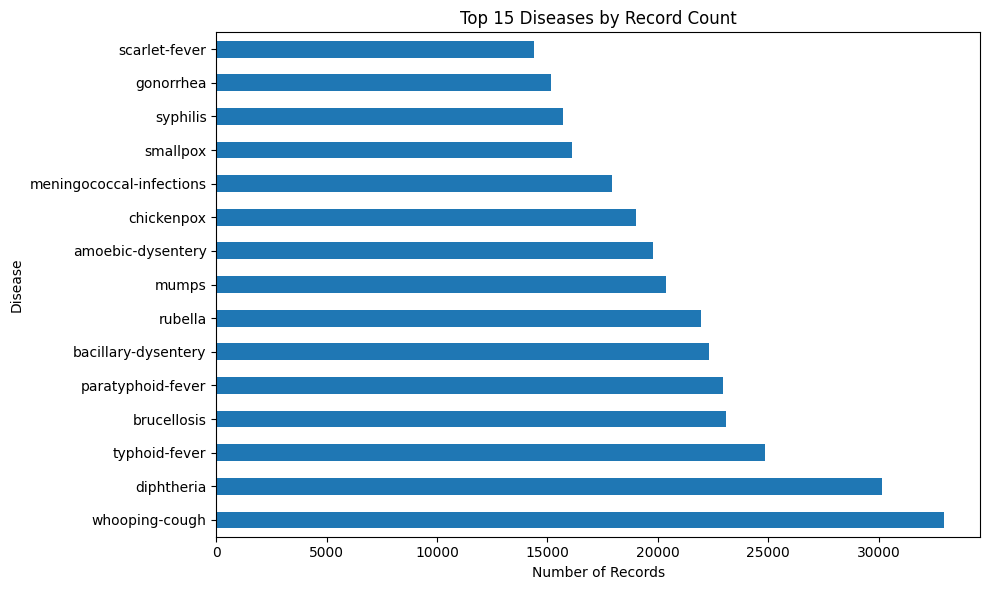

In [41]:
top_diseases = df["disease"].value_counts().head(15)

plt.figure(figsize=(10, 6))
ax = top_diseases.sort_values().plot(kind="barh")
ax.set_title("Top 15 Diseases by Record Count")
ax.set_xlabel("Number of Records")
ax.set_ylabel("Disease")
ax.invert_yaxis()

plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "top_diseases_record_count.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)

plt.show()

## 6. Disease Coverage by Time

A brief look at the disease representation by time span to ensure we can identity recurrences or outbreaks in the data. We've filtered it to the top twenty-five diseases

Saved: /content/drive/MyDrive/AAI-590-Capstone-Project/reports/figures/disease_year_heatmap.png


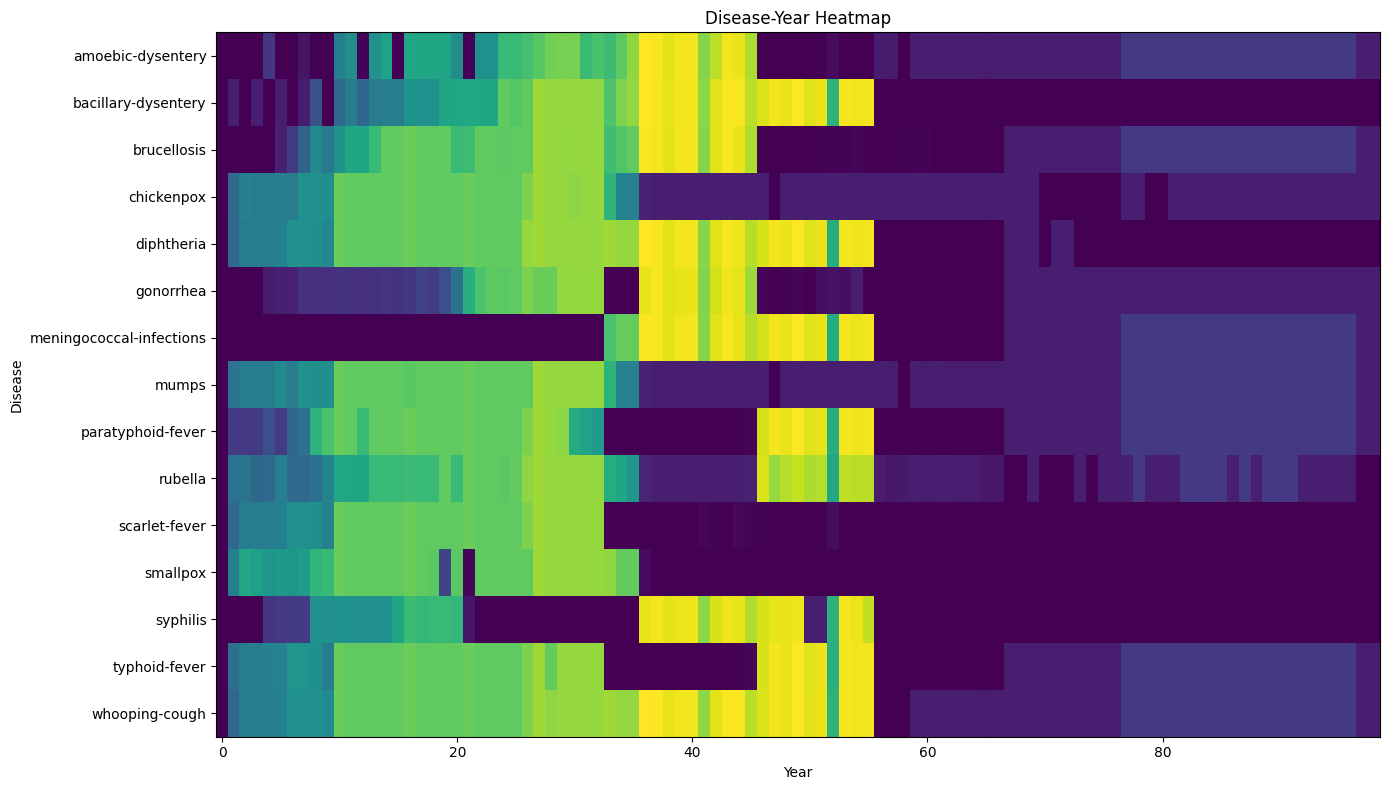

In [50]:
weekly = df[df['time_scale'] == 'wk'].copy()
weekly['year'] = weekly['period_start_date'].dt.year

disease_year = weekly.groupby(['disease', 'year']).size().unstack(fill_value=0)

heatmap_data = disease_year.loc[disease_year.index.isin(top_diseases.index)]

plt.figure(figsize=(14, 8))
plt.imshow(heatmap_data, aspect="auto")
plt.title("Disease-Year Heatmap")
plt.xlabel("Year")
plt.ylabel("Disease")
ax = plt.gca()
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_ylabel("Disease")

plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "disease_year_heatmap.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)

plt.show()

## 7. Focus Diseases — Coverage Check

Our three target diseases are **influenza**, **pertussis (whooping cough)**, and **measles**. All three are confirmed present in CANDID. We verify weekly record density and date ranges for each below.

In [46]:
focus_diseases = ['influenza', 'whooping-cough', 'measles']

for disease in focus_diseases:
    subset = df[df['disease'] == disease]
    wk = subset[subset['time_scale'] == 'wk']
    print(f"{disease}:")
    print(f"  Total records: {len(subset):,}  |  Weekly records: {len(wk):,}")
    print(f"  Date range: {subset['period_start_date'].min().date()} → {subset['period_start_date'].max().date()}")
    print(f"  Provinces: {sorted(subset['iso_3166_2'].unique())}")
    print()

influenza:
  Total records: 5,164  |  Weekly records: 4,900
  Date range: 1910-01-01 → 2021-12-26
  Provinces: ['CA-AB', 'CA-BC', 'CA-MB', 'CA-NB', 'CA-NL', 'CA-NS', 'CA-ON', 'CA-PE', 'CA-QC', 'CA-SK']

whooping-cough:
  Total records: 32,950  |  Weekly records: 30,059
  Date range: 1903-01-01 → 2021-12-26
  Provinces: ['CA-AB', 'CA-BC', 'CA-MB', 'CA-NB', 'CA-NL', 'CA-NS', 'CA-NT', 'CA-NU', 'CA-ON', 'CA-PE', 'CA-QC', 'CA-SK', 'CA-YT']

measles:
  Total records: 13,859  |  Weekly records: 11,164
  Date range: 1903-01-01 → 2019-12-22
  Provinces: ['CA-AB', 'CA-BC', 'CA-MB', 'CA-NB', 'CA-NL', 'CA-NS', 'CA-NT', 'CA-NU', 'CA-ON', 'CA-PE', 'CA-QC', 'CA-SK', 'CA-YT']



## 8. Sanity Check: Whooping Cough (Pertussis) Weekly Incidence

Pertussis has the largest record count of our focus diseases and shows notable geographic variation in the 1990s — a key finding from Earn et al. (2024). We plot Ontario and Quebec to visualize this pattern.

Saved: /content/drive/MyDrive/AAI-590-Capstone-Project/reports/figures/whooping_cough_on_qc_weekly.png


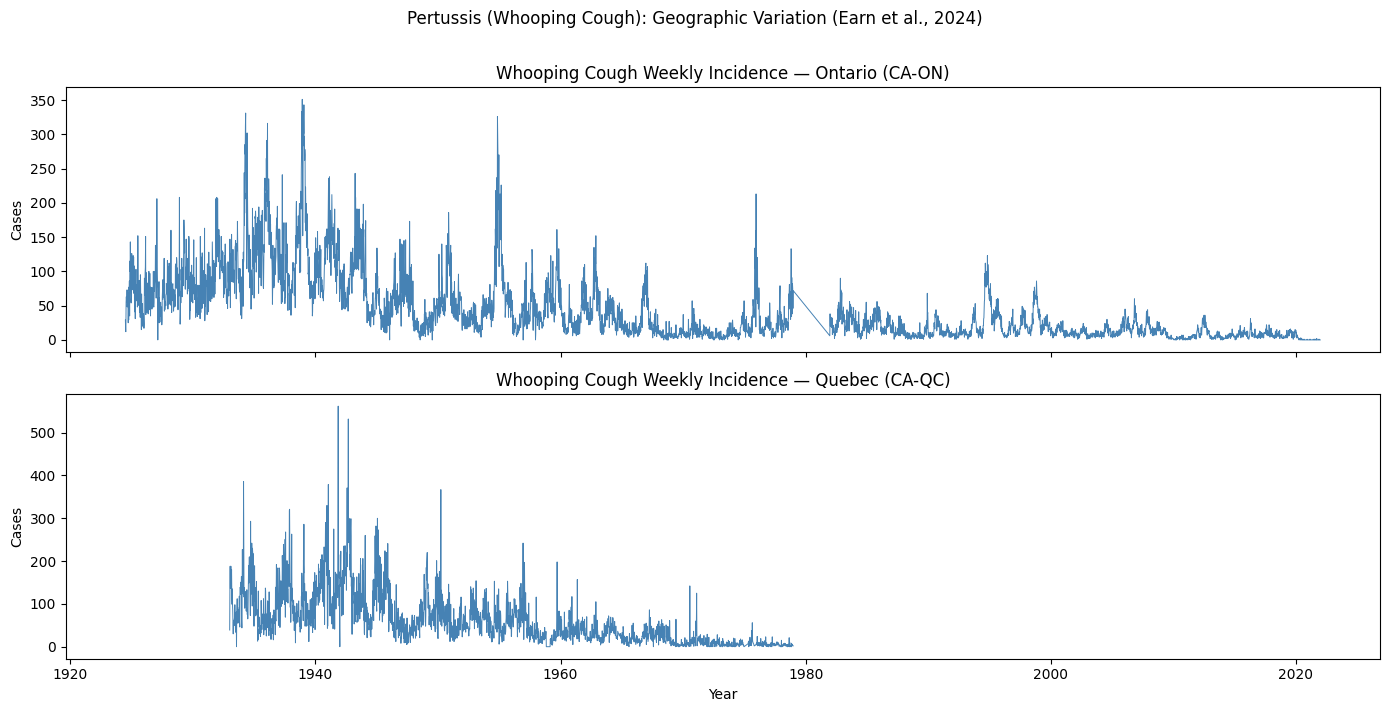

In [52]:
wc_on = filter_disease_province(df, disease='whooping-cough', province='CA-ON', time_scale='wk')
wc_qc = filter_disease_province(df, disease='whooping-cough', province='CA-QC', time_scale='wk')

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, prov_df, label in zip(axes, [wc_on, wc_qc], ['Ontario (CA-ON)', 'Quebec (CA-QC)']):
    ax.plot(prov_df['period_start_date'], prov_df['cases_this_period'], linewidth=0.7, color='steelblue')
    ax.set_ylabel('Cases')
    ax.set_title(f'Whooping Cough Weekly Incidence — {label}')

axes[-1].set_xlabel('Year')
plt.suptitle("Pertussis (Whooping Cough): Geographic Variation (Earn et al., 2024)", y=1.01)
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "whooping_cough_on_qc_weekly.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)

plt.show()

## 9. Secondary Dataset — PHAC Notifiable Diseases Extract

The Public Health Agency of Canada (PHAC) publishes official annual national case counts through its [Notifiable Diseases Online](https://diseases.canada.ca/notifiable/) system. We downloaded a Large Data Extract for our four focus disease categories:

- **Influenza, Epidemic** — 1924–1958
- **Influenza, Laboratory Confirmed** — 2000–2023
- **Measles** — 1924–2019
- **Pertussis** — 1924–2023

**Role:** This is a *complementary* dataset to CANDID. CANDID provides weekly provincial granularity needed for time-series modeling. PHAC provides official national annual aggregates useful for cross-validation and rate normalization.

**Source:** PHAC Notifiable Diseases Online — Large Data Extract  
**Downloaded:** 2026-03-06 | **Last modified:** 2025-06-12

In [54]:
PHAC_PATH = os.path.join(RAW_DIR, "phac-data.csv")

if not os.path.exists(PHAC_PATH):
    raise FileNotFoundError(f"File not found: {PHAC_PATH}")

phac = pd.read_csv(PHAC_PATH)
phac.columns = ["year", "disease", "cases", "rate_per_100k"]
phac["year"] = phac["year"].astype(int)

print("Loaded from:", PHAC_PATH)
print("Shape:", phac.shape)
phac.head()
print(f"Years: {phac['year'].min()} – {phac['year'].max()}")
print(f"Diseases: {phac['disease'].unique().tolist()}")
print()

# Null coverage by disease
for disease, grp in phac.groupby('disease'):
    with_cases = grp['cases'].notna().sum()
    years = grp.loc[grp['cases'].notna(), 'year']
    yr_range = f"{years.min()}–{years.max()}" if len(years) else 'none'
    print(f"{disease}")
    print(f"  Rows with case data: {with_cases}/{len(grp)}  |  Active years: {yr_range}")
    print()

Loaded from: /content/drive/MyDrive/AAI-590-Capstone-Project/data/raw/phac-data.csv
Shape: (400, 4)
Years: 1924 – 2023
Diseases: ['Influenza, Laboratory Confirmed', 'Measles', 'Pertussis', 'Influenza, Epidemic']

Influenza, Epidemic
  Rows with case data: 35/100  |  Active years: 1924–1958

Influenza, Laboratory Confirmed
  Rows with case data: 0/100  |  Active years: none

Measles
  Rows with case data: 90/100  |  Active years: 1924–2023

Pertussis
  Rows with case data: 100/100  |  Active years: 1924–2023



### 9.1 Harmonize Influenza Into a Single Series

PHAC tracked influenza under two successive labels in the CNDSS:
- **Influenza, Epidemic** — 1924–1958 (pre-modern surveillance era)
- **Influenza, Laboratory Confirmed** — added to the notifiable disease list in 2000

We attempted to include both in this extract. However, `Influenza, Laboratory Confirmed` returns no records from the CNDSS Large Data Extract — confirmed both by the empty CSV rows and by a direct query to the PHAC Notifiable Diseases Online tool, which returned: *"Your search did not match any records."*

Per the PHAC notes accompanying this extract, modern influenza surveillance is conducted through the [**FluWatch program**](https://www.canada.ca/en/public-health/services/diseases/flu-influenza/influenza-surveillance/weekly-influenza-reports.html) (a separate stream from CNDSS), which is why lab-confirmed data is absent here. The FluWatch program reports weekly, and seasonal, datasets, but this weekly data should be reflected in CANDID already.

**Decision:** We drop `Influenza, Laboratory Confirmed` from the PHAC extract after confirming it is empty. The PHAC influenza series covers the epidemic era only (1924–1958). For modern influenza data, CANDID's `influenza` key (4,900 weekly records, 1910–2021) is the authoritative source and is used exclusively for modeling.

In [55]:
flu_mask = phac['disease'].isin(['Influenza, Epidemic', 'Influenza, Laboratory Confirmed'])
flu = phac[flu_mask].copy()

# Step 1: Check data availability for each influenza label
for label in ['Influenza, Epidemic', 'Influenza, Laboratory Confirmed']:
    rows = flu[flu['disease'] == label]
    n_with_data = rows['cases'].notna().sum()
    years = rows.loc[rows['cases'].notna(), 'year']
    yr_str = f"{years.min()}–{years.max()}" if n_with_data else "NO DATA"
    print(f"{label}: {n_with_data}/{len(rows)} rows with data  |  {yr_str}")

# Step 2: Confirm lab-confirmed is entirely null — then drop it
lab_confirmed = flu[flu['disease'] == 'Influenza, Laboratory Confirmed']
assert lab_confirmed['cases'].isna().all(), "Unexpected data found in Influenza, Laboratory Confirmed — review before proceeding"
print("\nInfluenza, Laboratory Confirmed confirmed empty. Dropping from PHAC extract.")
print("Modern influenza data sourced exclusively from CANDID (influenza key, 1910–2021).")

# Step 3: Build influenza series from epidemic label only
flu_epidemic = flu[flu['disease'] == 'Influenza, Epidemic'][['year', 'cases', 'rate_per_100k']].copy()
flu_epidemic['disease'] = 'influenza'

# Step 4: Combine with measles and pertussis
other = phac[~flu_mask][['year', 'disease', 'cases', 'rate_per_100k']].copy()
other['disease'] = other['disease'].str.lower()

phac_clean = pd.concat([flu_epidemic, other], ignore_index=True).sort_values(['disease', 'year']).reset_index(drop=True)

print(f"\nProcessed PHAC table: {phac_clean.shape}")
phac_clean[phac_clean['cases'].notna()].groupby('disease').agg(
    years_with_data=('year', 'count'),
    year_min=('year', 'min'),
    year_max=('year', 'max'),
    total_cases=('cases', 'sum')
)

Influenza, Epidemic: 35/100 rows with data  |  1924–1958
Influenza, Laboratory Confirmed: 0/100 rows with data  |  NO DATA

Influenza, Laboratory Confirmed confirmed empty. Dropping from PHAC extract.
Modern influenza data sourced exclusively from CANDID (influenza key, 1910–2021).

Processed PHAC table: (300, 4)


,years_with_data,year_min,year_max,total_cases
disease,,,,
influenza,35,1924,1958,628774.0
measles,90,1924,2023,1814405.0
pertussis,100,1924,2023,633544.0


### 9.2 Cross-Validation Against CANDID

We compare PHAC national annual totals against CANDID aggregated to the same level. This validates consistency between the two sources.

**Expected differences:**
- CANDID aggregates weekly provincial records; PHAC is the official annual national total — they should be close.
- CANDID ends at 2021; PHAC extends to 2023 for influenza and pertussis

Overlapping year × disease pairs: 219
Saved: /content/drive/MyDrive/AAI-590-Capstone-Project/reports/figures/phac_vs_candid_scatter.png


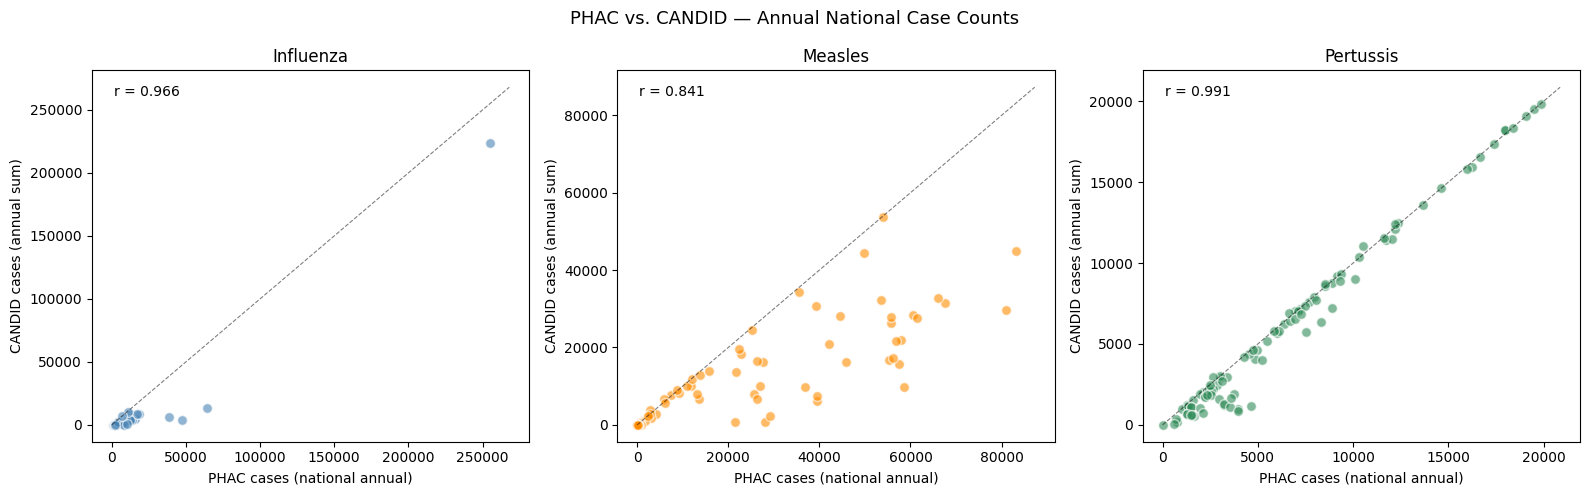

In [57]:
disease_map = {
    'influenza':      'influenza',
    'whooping-cough': 'pertussis',
    'measles':        'measles',
}

candid_focus = df[df['disease'].isin(disease_map)].copy()
candid_focus['disease_harmonized'] = candid_focus['disease'].map(disease_map)
candid_focus['year'] = candid_focus['period_start_date'].dt.year

candid_annual = (
    candid_focus.groupby(['year', 'disease_harmonized'], as_index=False)
                .agg(candid_cases=('cases_this_period', 'sum'))
                .rename(columns={'disease_harmonized': 'disease'})
)

comparison = candid_annual.merge(
    phac_clean[['year', 'disease', 'cases']].rename(columns={'cases': 'phac_cases'}),
    on=['year', 'disease'],
    how='inner'
).dropna(subset=['phac_cases'])

print(f"Overlapping year × disease pairs: {len(comparison)}")

colors = {'influenza': 'steelblue', 'measles': 'darkorange', 'pertussis': 'seagreen'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, disease in zip(axes, ['influenza', 'measles', 'pertussis']):
    d = comparison[comparison['disease'] == disease]
    ax.scatter(d['phac_cases'], d['candid_cases'], alpha=0.6, color=colors[disease], edgecolors='white', s=50)
    lim = max(d['phac_cases'].max(), d['candid_cases'].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8, alpha=0.5, label='y=x')
    ax.set_xlabel('PHAC cases (national annual)')
    ax.set_ylabel('CANDID cases (annual sum)')
    ax.set_title(disease.title())
    corr = d[['phac_cases', 'candid_cases']].corr().iloc[0, 1]
    ax.text(0.05, 0.93, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10)

plt.suptitle("PHAC vs. CANDID — Annual National Case Counts", fontsize=13)
plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, "phac_vs_candid_scatter.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)

plt.show()

### 9.3 Dataset Comparison Summary

| Dimension | CANDID (`canmod-cdi-normalized`) | PHAC Large Extract |
|-----------|----------------------------------|--------------------|
| Granularity | Weekly | Annual |
| Geography | Provincial (13 provinces/territories) | National aggregate |
| Coverage | 1903–2021 | 1924–2023 |
| Influenza | `influenza` key | Epidemic 1924–1958; Lab Confirmed 2000–2023 |
| Population | Per-row population field | Rate per 100,000 computed |
| Role | **Primary modeling dataset** | **Cross-validation + rate normalization** |

## 10. Go Forward Decision: CANDID Dataset of Three Diseases

**Decision:** CANDID remains the primary modeling dataset. The PHAC extract is used to:
1. Validate CANDID national aggregates are consistent with official PHAC counts
2. Provide `rate_per_100k` as a supplementary normalized feature if needed
3. Extend coverage to 2022–2023 for influenza and pertussis where CANDID ends at 2021

The processed PHAC table is saved to `data/processed/phac-clean.csv` for data organization and cleanliness.

In [58]:
import os
os.makedirs('../data/processed', exist_ok=True)

phac_clean.to_csv('../data/processed/phac-clean.csv', index=False)
print('Saved: ../data/processed/phac-clean.csv')
print(f'Shape: {phac_clean.shape}')
phac_clean.head(5)

Saved: ../data/processed/phac-clean.csv
Shape: (300, 4)


,year,cases,rate_per_100k,disease
0,1924,820.0,9.71,influenza
1,1925,1746.0,20.32,influenza
2,1926,3510.0,40.13,influenza
3,1927,1221.0,13.71,influenza
4,1928,15551.0,171.34,influenza


## 11. EDA — CANDID Focus Diseases

This section reuses variables established earlier in the notebook.
- `weekly` — CANDID filtered to `time_scale == 'wk'` with a `year` column
- `focus_diseases` — `['influenza', 'whooping-cough', 'measles']`
- `disease_map` — CANDID key → harmonized name mapping

In [59]:
# EDA Setup
focus_weekly = weekly[weekly['disease'].isin(focus_diseases)].copy()

disease_labels = {
    'influenza':      'Influenza',
    'whooping-cough': 'Pertussis (Whooping Cough)',
    'measles':        'Measles',
}
eda_colors = {
    'influenza':      'steelblue',
    'whooping-cough': 'seagreen',
    'measles':        'darkorange',
}

print("Focus disease weekly record counts:")
for d in focus_diseases:
    n = len(focus_weekly[focus_weekly['disease'] == d])
    print(f"  {disease_labels[d]}: {n:,}")

Focus disease weekly record counts:
  Influenza: 4,900
  Pertussis (Whooping Cough): 30,059
  Measles: 11,164


### 11.1 National Weekly Time Series

Aggregate all provinces to produce a single national weekly series per disease.

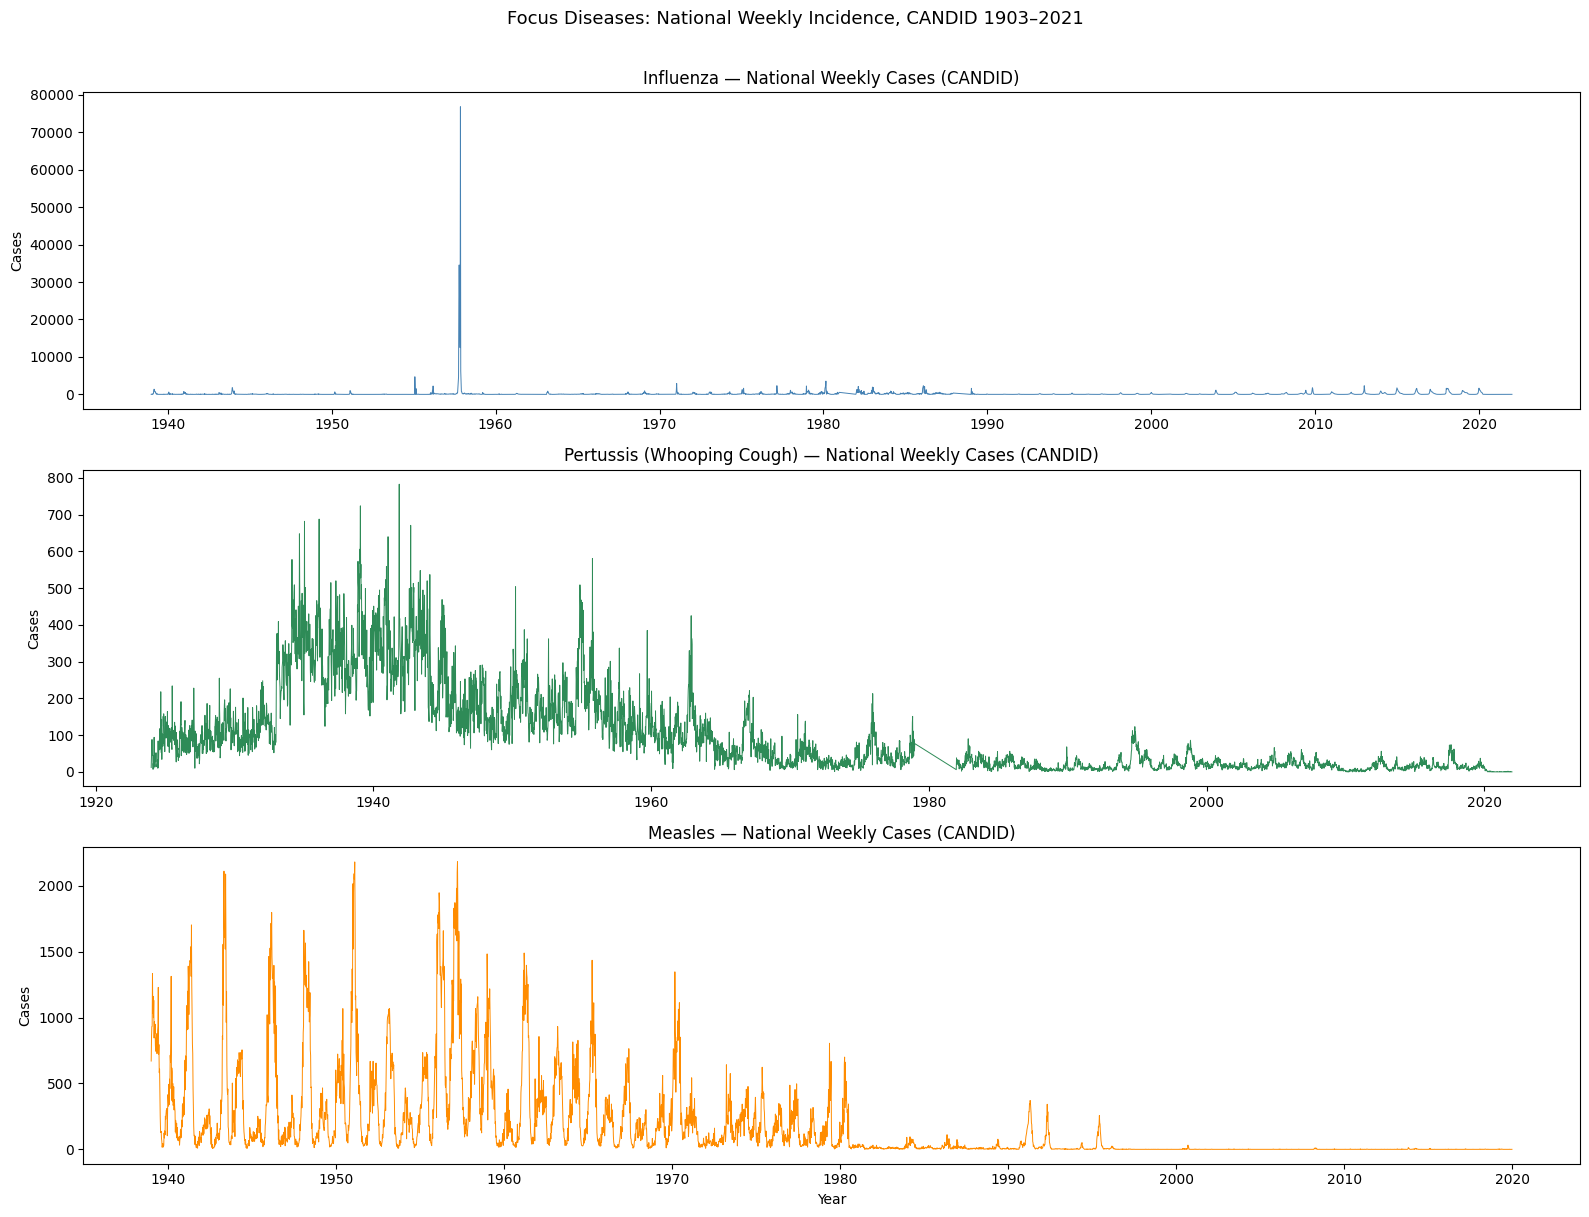

In [61]:
national_weekly = (
    focus_weekly.groupby(['disease', 'period_start_date'], as_index=False)
                .agg(cases=('cases_this_period', 'sum'))
)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)

for ax, disease in zip(axes, focus_diseases):
    d = national_weekly[national_weekly['disease'] == disease].sort_values('period_start_date')
    ax.plot(d['period_start_date'], d['cases'], linewidth=0.7, color=eda_colors[disease])
    ax.set_title(f'{disease_labels[disease]} — National Weekly Cases (CANDID)')
    ax.set_ylabel('Cases')

axes[-1].set_xlabel('Year')
plt.suptitle('Focus Diseases: National Weekly Incidence, CANDID 1903–2021', fontsize=13, y=1.01)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "eda_national_weekly_timeseries.png")
plt.savefig(fig_path, dpi=150)
plt.show()

### 11.2 Seasonality

Average weekly cases by week-of-year across all available years to expose cyclical patterns. We would expect influenza is expected to peak in winter weeks, while we would expect measles and pertussis to reflect multi-year epidemic cycles.

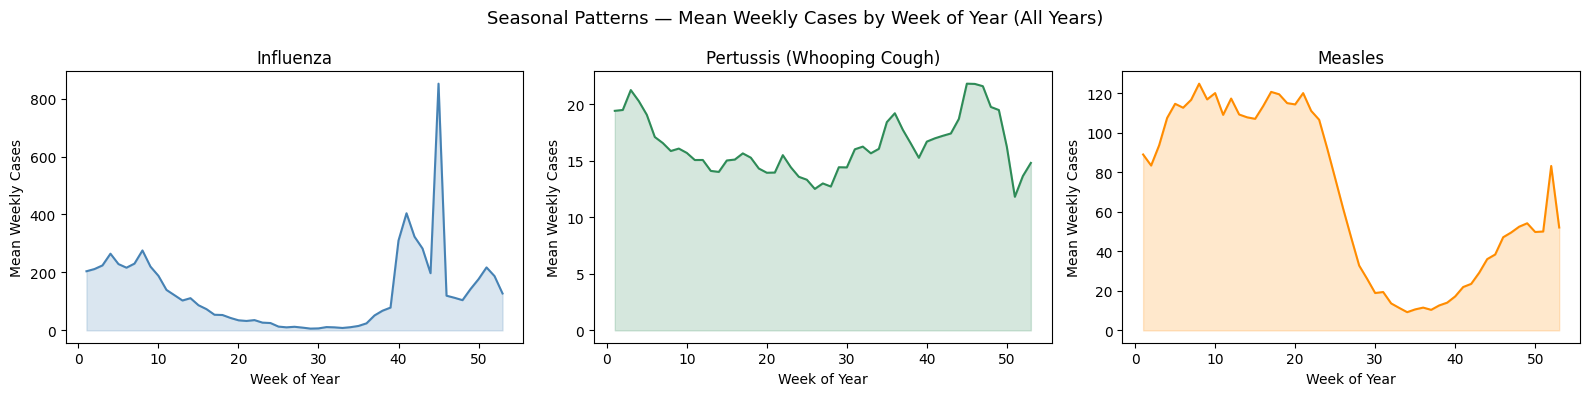

In [62]:
focus_weekly['week_of_year'] = focus_weekly['period_start_date'].dt.isocalendar().week.astype(int)

seasonal = (
    focus_weekly.groupby(['disease', 'week_of_year'])['cases_this_period']
                .mean()
                .reset_index()
                .rename(columns={'cases_this_period': 'mean_cases'})
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, disease in zip(axes, focus_diseases):
    d = seasonal[seasonal['disease'] == disease].sort_values('week_of_year')
    ax.plot(d['week_of_year'], d['mean_cases'], color=eda_colors[disease], linewidth=1.5)
    ax.fill_between(d['week_of_year'], d['mean_cases'], alpha=0.2, color=eda_colors[disease])
    ax.set_title(disease_labels[disease])
    ax.set_xlabel('Week of Year')
    ax.set_ylabel('Mean Weekly Cases')

plt.suptitle('Seasonal Patterns — Mean Weekly Cases by Week of Year (All Years)', fontsize=13)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "eda_seasonality.png")
plt.savefig(fig_path, dpi=150)
plt.show()

### 11.3 Province-Level Record Breakdown

Understanding which provinces have the most weekly records per disease helps us select modeling targets. Provinces with sparse coverage will be excluded or treated carefully during train/test splits.

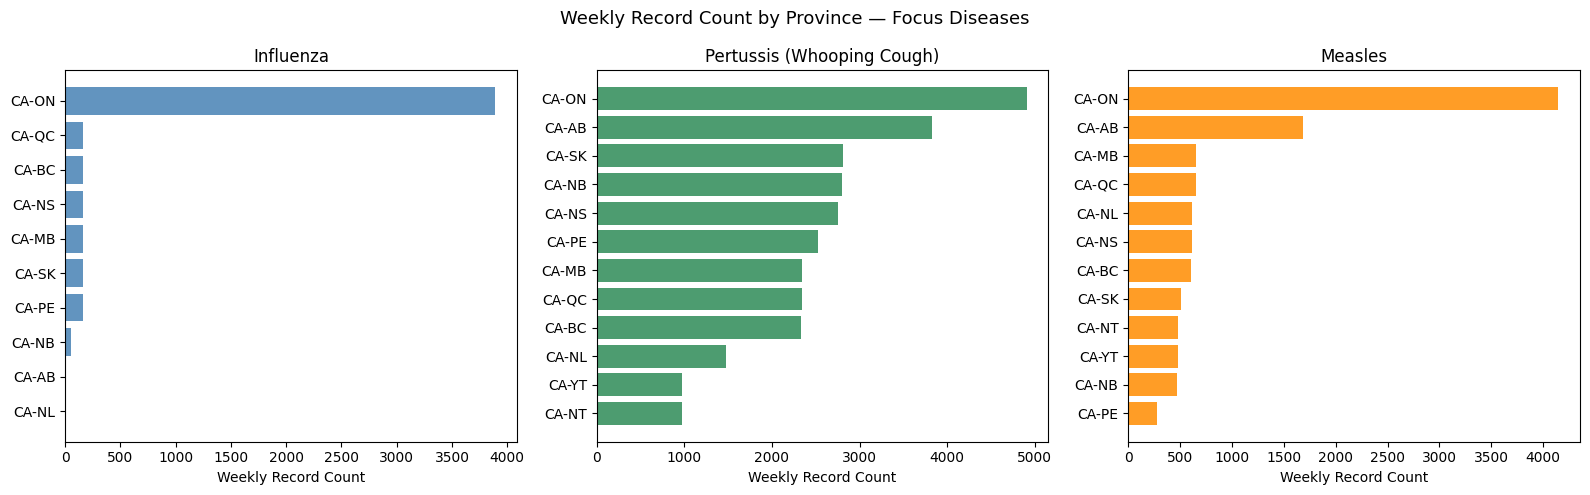

Influenza — top 3 provinces by record count:
iso_3166_2  record_count  total_cases
     CA-ON          3893     445073.0
     CA-BC           159     156579.0
     CA-MB           159      29257.0

Pertussis (Whooping Cough) — top 3 provinces by record count:
iso_3166_2  record_count  total_cases
     CA-ON          4911     208202.0
     CA-AB          3823      30767.0
     CA-SK          2811      22112.0

Measles — top 3 provinces by record count:
iso_3166_2  record_count  total_cases
     CA-ON          4149     627386.0
     CA-AB          1680      27875.0
     CA-MB           654      12584.0



In [63]:
prov_disease = (
    focus_weekly.groupby(['disease', 'iso_3166_2'])['cases_this_period']
                .agg(record_count='count', total_cases='sum')
                .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, disease in zip(axes, focus_diseases):
    d = prov_disease[prov_disease['disease'] == disease].sort_values('record_count')
    ax.barh(d['iso_3166_2'], d['record_count'], color=eda_colors[disease], alpha=0.85)
    ax.set_title(disease_labels[disease])
    ax.set_xlabel('Weekly Record Count')

plt.suptitle('Weekly Record Count by Province — Focus Diseases', fontsize=13)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "eda_province_breakdown.png")
plt.savefig(fig_path, dpi=150)
plt.show()

# Top 3 provinces per disease
for disease in focus_diseases:
    top = (prov_disease[prov_disease['disease'] == disease]
           .nlargest(3, 'record_count')[['iso_3166_2', 'record_count', 'total_cases']])
    print(f"{disease_labels[disease]} — top 3 provinces by record count:")
    print(top.to_string(index=False))
    print()

### 11.4 Data Gaps and Coverage by Province × Year

A heatmap of weekly record counts per province per year reveals where coverage is sparse or absent (this is similar to what we ran earlier, in sections 6 and 7.)

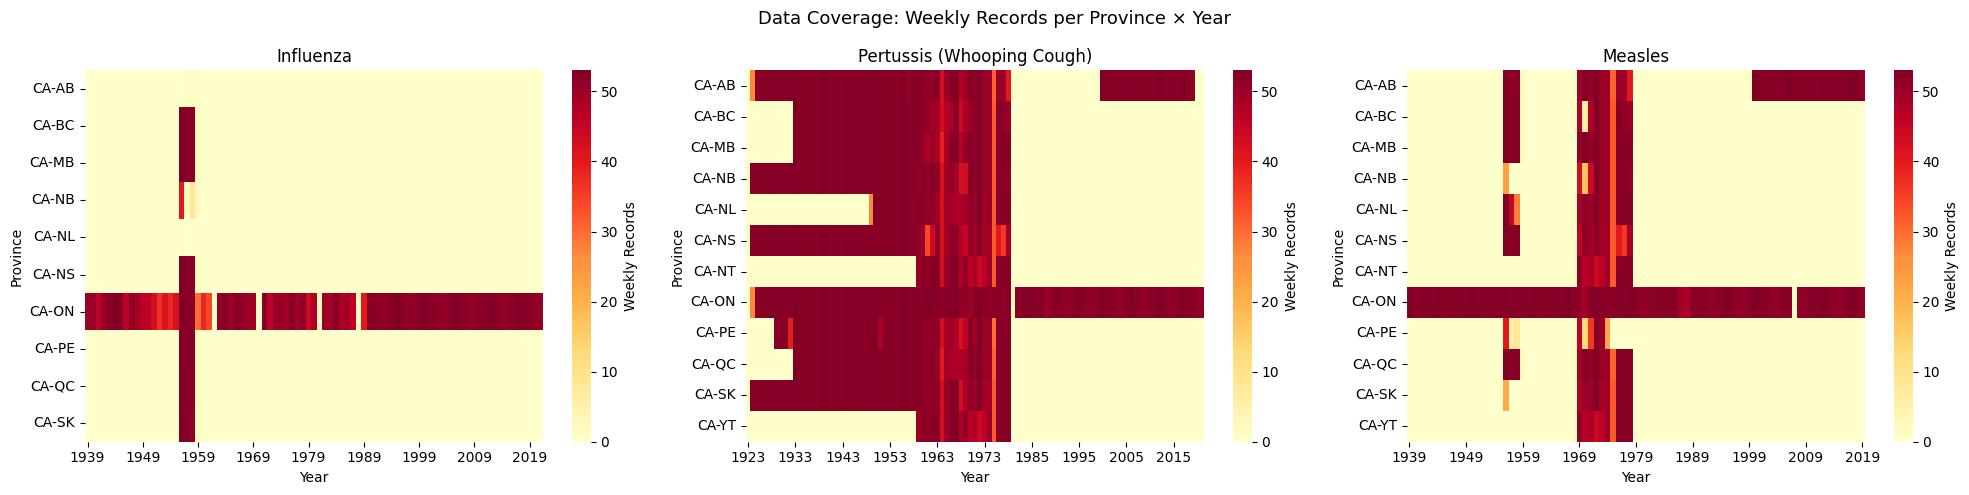

In [64]:
year_prov_counts = (
    focus_weekly.groupby(['disease', 'iso_3166_2', 'year'])['cases_this_period']
                .count()
                .reset_index()
                .rename(columns={'cases_this_period': 'n_weeks'})
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, disease in zip(axes, focus_diseases):
    d = year_prov_counts[year_prov_counts['disease'] == disease]
    pivot = d.pivot(index='iso_3166_2', columns='year', values='n_weeks').fillna(0)
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', cbar_kws={'label': 'Weekly Records'},
                linewidths=0, xticklabels=10)
    ax.set_title(disease_labels[disease])
    ax.set_xlabel('Year')
    ax.set_ylabel('Province')

plt.suptitle('Data Coverage: Weekly Records per Province × Year', fontsize=13)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "eda_coverage_heatmap.png")
plt.savefig(fig_path, dpi=150)
plt.show()

### 11.5 Descriptive Statistics

Summary statistics for weekly case counts per disease.

In [65]:
desc = (
    focus_weekly.groupby('disease')['cases_this_period']
                .describe()
                .rename(index=disease_labels)
                .round(1)
)

print("Descriptive Statistics — Weekly Cases by Disease (CANDID, all provinces)")
desc

Descriptive Statistics — Weekly Cases by Disease (CANDID, all provinces)


,count,mean,std,min,25%,50%,75%,max
disease,,,,,,,,
Influenza,4900.0,136.3,1206.8,0.0,1.0,12.0,70.0,72072.0
Measles,11163.0,68.5,191.0,0.0,0.0,3.0,35.0,2181.0
Pertussis (Whooping Cough),30057.0,16.4,33.6,0.0,0.0,3.0,16.0,562.0


### 11.6 Autocorrelation Structure (ACF/PACF)

ACF and PACF plots on the national weekly series directly inform model design:
- **ACF** shows overall temporal dependence and seasonality lags
- **PACF** reveals the direct lag relationships that inform ARIMA order selection

We plot 52 lags (one full year) on the national aggregated series per disease. Gaps in the series are filled with zero for the purposes of this analysis.

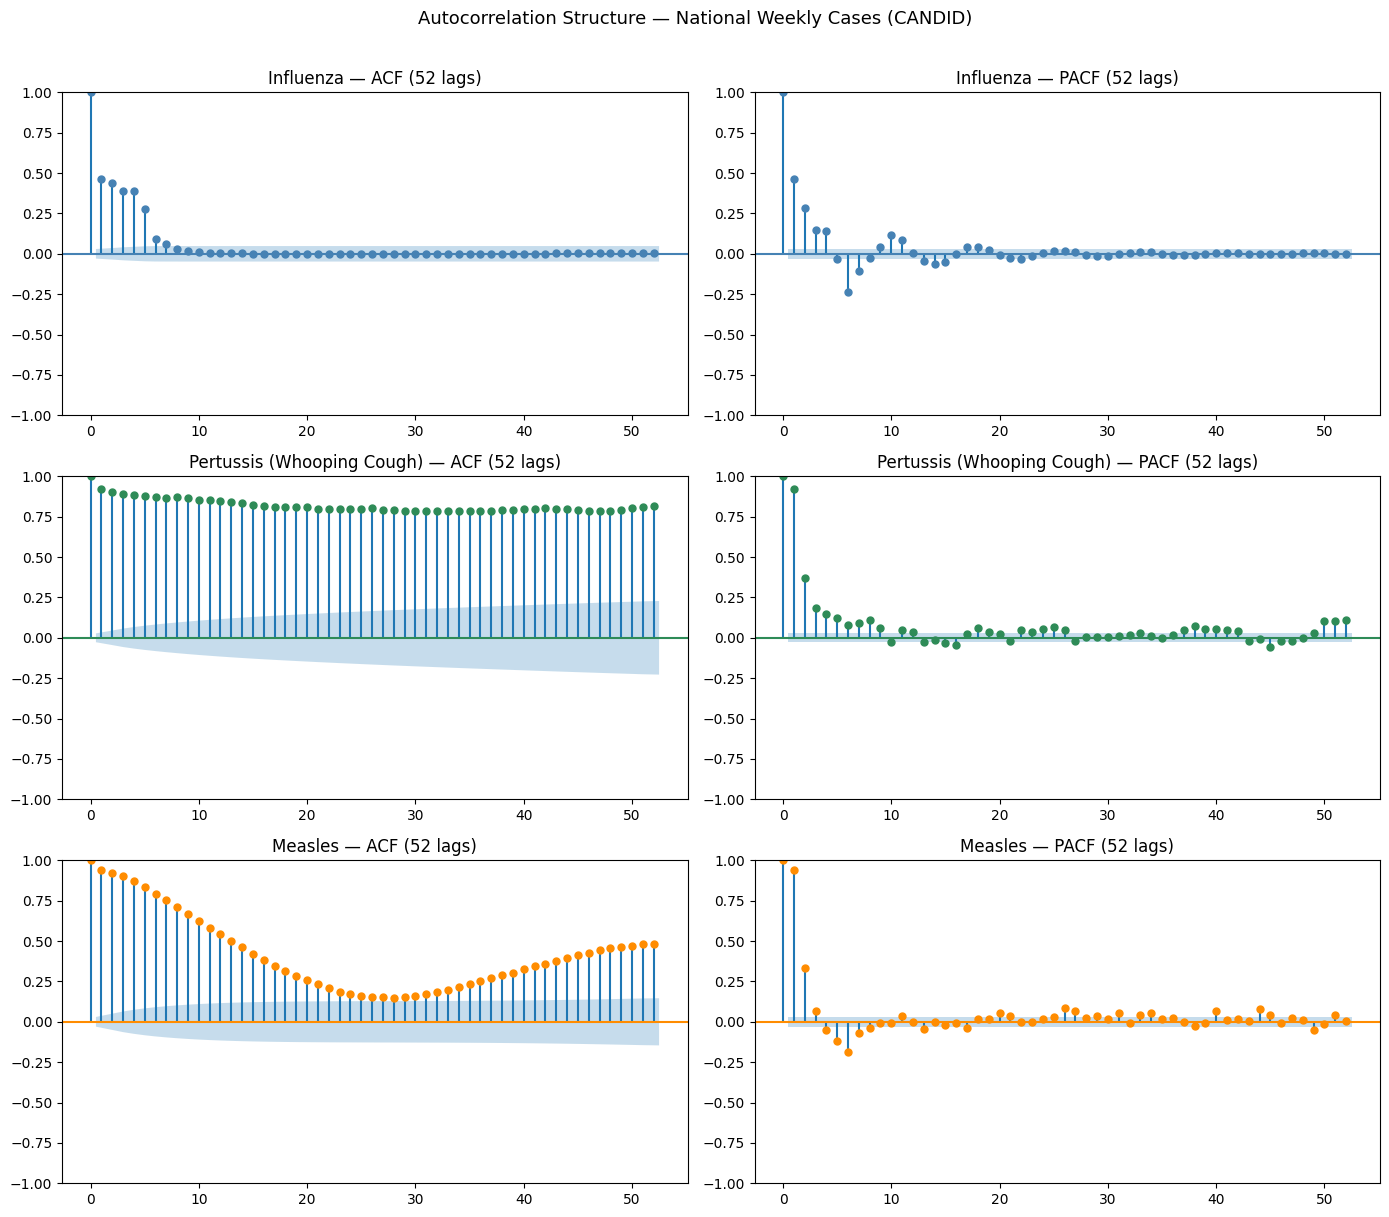

In [66]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, disease in enumerate(focus_diseases):
    series = (
        national_weekly[national_weekly['disease'] == disease]
        .set_index('period_start_date')['cases']
        .resample('W').sum()
        .fillna(0)
    )
    plot_acf(series, lags=52, ax=axes[i, 0], color=eda_colors[disease],
             title=f'{disease_labels[disease]} — ACF (52 lags)')
    plot_pacf(series, lags=52, ax=axes[i, 1], color=eda_colors[disease],
              title=f'{disease_labels[disease]} — PACF (52 lags)')

plt.suptitle('Autocorrelation Structure — National Weekly Cases (CANDID)', fontsize=13, y=1.01)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "eda_acf_pacf.png")
plt.savefig(fig_path, dpi=150)
plt.show()

### 12. Data Split

Time-Series Data Split  (70% Train / 15% Validation / 15% Test)
Applied to the primary CANDID dataset

For time-series forecasting, splits must be strictly chronological to prevent data leakage. Boundaries are placed at year edges to avoid splitting multi-week or multi-month reporting periods across sets.

- CANDID date range : 1903-01-01 → 2021-12-26  (~119 years)
- Train  cutoff     : period_start_date <  1986-01-01  (83 yrs  ≈ 70%)
- Val    cutoff     : period_start_date <  2004-01-01  (18 yrs  ≈ 15%)
- Test              : period_start_date >= 2004-01-01  (18 yrs  ≈ 15%)


In [67]:
import pandas as pd

TRAIN_CUTOFF = pd.Timestamp("1986-01-01")
VAL_CUTOFF   = pd.Timestamp("2004-01-01")

def assign_split(date):
    if date < TRAIN_CUTOFF:
        return "train"
    elif date < VAL_CUTOFF:
        return "validation"
    else:
        return "test"

df["split"] = df["period_start_date"].apply(assign_split)

# ── Verification ──────────────────────────────────────────────────────────────
print("=" * 65)
print("CANDID Dataset — Chronological Train / Validation / Test Split")
print("=" * 65)

for s in ["train", "validation", "test"]:
    subset   = df[df["split"] == s]
    n        = len(subset)
    pct      = n / len(df) * 100
    yr_min   = subset["period_start_date"].min().strftime("%Y-%m-%d")
    yr_max   = subset["period_start_date"].max().strftime("%Y-%m-%d")
    diseases = subset["disease"].nunique()
    provs    = subset["iso_3166_2"].nunique()
    print(f"\n  {s.upper():<12}")
    print(f"    Rows         : {n:>9,}  ({pct:.1f}%)")
    print(f"    Date range   : {yr_min}  →  {yr_max}")
    print(f"    Diseases     : {diseases}")
    print(f"    Provinces    : {provs}")

print(f"\n  TOTAL ROWS: {len(df):,}")
print("=" * 65)

CANDID Dataset — Chronological Train / Validation / Test Split

  TRAIN       
    Rows         :   700,883  (75.0%)
    Date range   : 1903-01-01  →  1985-12-29
    Diseases     : 170
    Provinces    : 12

  VALIDATION  
    Rows         :   103,774  (11.1%)
    Date range   : 1986-01-05  →  2003-12-28
    Diseases     : 132
    Provinces    : 13

  TEST        
    Rows         :   129,353  (13.8%)
    Date range   : 2004-01-01  →  2021-12-26
    Diseases     : 204
    Provinces    : 13

  TOTAL ROWS: 934,010


In [68]:
df.head()

,iso_3166,iso_3166_2,period_start_date,period_end_date,disease,nesting_disease,basal_disease,cases_this_period,location,location_type,time_scale,historical_disease,historical_disease_family,historical_disease_subclass,days_this_period,period_mid_date,population,record_origin,original_dataset_id,digitization_id,scan_id,split
0,CA,CA-ON,1903-01-01,1903-01-31,smallpox,NaN,smallpox,196.0,ONT.,province,mo,Small-pox,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn,train
1,CA,CA-ON,1903-01-01,1903-01-31,scarlet-fever,NaN,scarlet-fever,500.0,ONT.,province,mo,Scarlatina,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn,train
2,CA,CA-ON,1903-01-01,1903-01-31,diphtheria,NaN,diphtheria,510.0,ONT.,province,mo,Diphtheria,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn,train
3,CA,CA-ON,1903-01-01,1903-01-31,measles,NaN,measles,6.0,ONT.,province,mo,Measles,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn,train
4,CA,CA-ON,1903-01-01,1903-01-31,whooping-cough,NaN,whooping-cough,9.0,ONT.,province,mo,Whooping cough,NaN,NaN,31,1903-01-16,2252721,historical,cdi_on_1903-1939_mn,cdi_mort_on_1903-1939_mn,cdi_on_1903-1939_mn,train


In [69]:
# Save Processed CANDID Dataset with Split Column

OUTPUT_PATH = '../data/processed/candid_data_split.csv'
df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved : {OUTPUT_PATH}")
print(f"Shape : {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
print(f"\nSplit column value counts:")
print(df["split"].value_counts().reindex(["train", "validation", "test"]))

Saved : ../data/processed/candid_data_split.csv
Shape : (934010, 22)
Columns (22): ['iso_3166', 'iso_3166_2', 'period_start_date', 'period_end_date', 'disease', 'nesting_disease', 'basal_disease', 'cases_this_period', 'location', 'location_type', 'time_scale', 'historical_disease', 'historical_disease_family', 'historical_disease_subclass', 'days_this_period', 'period_mid_date', 'population', 'record_origin', 'original_dataset_id', 'digitization_id', 'scan_id', 'split']

Split column value counts:
split
train         700883
validation    103774
test          129353
Name: count, dtype: int64


## 13. Validate Dataset Structure and Split

In [70]:
# Dataset structure validation
print("CANDID Dataset - Structure Validation:")

print(f"Rows: {len(df):,}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("Columns:")
print(df.columns.tolist())

CANDID Dataset - Structure Validation:
Rows: 934,010
Columns (22): ['iso_3166', 'iso_3166_2', 'period_start_date', 'period_end_date', 'disease', 'nesting_disease', 'basal_disease', 'cases_this_period', 'location', 'location_type', 'time_scale', 'historical_disease', 'historical_disease_family', 'historical_disease_subclass', 'days_this_period', 'period_mid_date', 'population', 'record_origin', 'original_dataset_id', 'digitization_id', 'scan_id', 'split']
Missing values: 2337512
Duplicate rows: 0
Columns:
['iso_3166', 'iso_3166_2', 'period_start_date', 'period_end_date', 'disease', 'nesting_disease', 'basal_disease', 'cases_this_period', 'location', 'location_type', 'time_scale', 'historical_disease', 'historical_disease_family', 'historical_disease_subclass', 'days_this_period', 'period_mid_date', 'population', 'record_origin', 'original_dataset_id', 'digitization_id', 'scan_id', 'split']


### 13.1 Missing Values by Column

In [71]:
# Summarize missing values by column
missing_sum = (
    df.isna()
    .sum()
    .reset_index()
)

missing_sum.columns = ["column", "missing_count"]
missing_sum["missing_percent"] = (missing_sum["missing_count"] / len(df) * 100).round(2)
missing_sum = missing_sum.sort_values("missing_count", ascending=False)

print("Missing value summary:")
missing_sum.head(20)

Missing value summary:


,column,missing_count,missing_percent
12,historical_disease_family,855935,91.64
13,historical_disease_subclass,805452,86.24
5,nesting_disease,476408,51.01
20,scan_id,167874,17.97
11,historical_disease,15905,1.70
18,original_dataset_id,15905,1.70
7,cases_this_period,33,0.00
4,disease,0,0.00
2,period_start_date,0,0.00
1,iso_3166_2,0,0.00


### 13.2 Duplicate Check by Province, Disease, and Week

In [72]:
duplicates = df.duplicated(subset=["iso_3166_2", "disease", "period_start_date"]).sum()

print("CANDID Dataset - Duplicate Check:")
print(f"Duplicate province, disease, week rows: {duplicates:,}")

CANDID Dataset - Duplicate Check:
Duplicate province, disease, week rows: 1


### 13.3 Review Duplicate Province-Disease-Week Record

In [73]:
duplicate_rows = (
    df[df.duplicated(subset=["iso_3166_2", "disease", "period_start_date"], keep=False)]
    .sort_values(["iso_3166_2", "disease", "period_start_date"])
)

print(f"Rows flagged in the duplicate key check: {len(duplicate_rows)}")
duplicate_rows

Rows flagged in the duplicate key check: 2


,iso_3166,iso_3166_2,period_start_date,period_end_date,disease,nesting_disease,basal_disease,cases_this_period,location,location_type,time_scale,historical_disease,historical_disease_family,historical_disease_subclass,days_this_period,period_mid_date,population,record_origin,original_dataset_id,digitization_id,scan_id,split
864921,CA,CA-MB,2011-03-01,2011-03-31,congenital-rubella,rubella,rubella,0.0,Manitoba,province,mo,RUBELLA CONGENITAL,NaN,NaN,31,2011-03-16,1236825,historical,cdi_man_2011_mn,cdi_man_2011_mn,cdi_man_2011_mn_age_sex,test
864922,CA,CA-MB,2011-03-01,2011-03-31,congenital-rubella,rubella,rubella,0.0,Manitoba,province,mo,RUBELLA CONGENTIAL,NaN,NaN,31,2011-03-16,1236825,historical,cdi_man_2011_mn,cdi_man_2011_mn,cdi_man_2011_mn_age_sex,test


### 13.4 Split Check

In [74]:
df["period_start_date"] = pd.to_datetime(df["period_start_date"])

# Convert dates and summarize count for each split
split_sum = (
    df.groupby("split")["period_start_date"]
    .agg(["min", "max", "count"])
    .reset_index()
)
print("Split Summary: ")
split_sum

Split Summary: 


,split,min,max,count
0,test,2004-01-01,2021-12-26,129353
1,train,1903-01-01,1985-12-29,700883
2,validation,1986-01-05,2003-12-28,103774


In [75]:
# Find date boundaries for the train, val, and test splits
train_end = df.loc[df["split"] == "train", "period_start_date"].max()
val_start = df.loc[df["split"] == "validation", "period_start_date"].min()
val_end = df.loc[df["split"] == "validation", "period_start_date"].max()
test_start = df.loc[df["split"] == "test", "period_start_date"].min()

# Check if the train/val split ends on or before test/val starts
train_val_ok = train_end <= val_start
val_test_ok = val_end <= test_start

print("CANDID Dataset — Chronological Split Val:")

print()
print(f"Train comes before validation : {train_val_ok}")
print(f"Validation comes before test  : {val_test_ok}")

print()
print(f"Train max date      : {train_end}")
print(f"Validation min date : {val_start}")
print(f"Validation max date : {val_end}")
print(f"Test min date       : {test_start}")

CANDID Dataset — Chronological Split Val:

Train comes before validation : True
Validation comes before test  : True

Train max date      : 1985-12-29 00:00:00
Validation min date : 1986-01-05 00:00:00
Validation max date : 2003-12-28 00:00:00
Test min date       : 2004-01-01 00:00:00


### 13.5 Validation Summary

In [76]:
val_sum = pd.DataFrame([
    {
        "check": "dataset_rows",
        "status": "PASS" if len(df) > 0 else "FAIL",
        "details": f"{len(df):,} rows"
    },
    {
        "check": "dataset_cols",
        "status": "PASS" if len(df.columns) > 0 else "FAIL",
        "details": f"{len(df.columns)} columns"
    },
    {
        "check": "split_col_exists",
        "status": "PASS" if "split" in df.columns else "FAIL",
        "details": "split column exists" if "split" in df.columns else "split column is missing"
    },
    {
        "check": "duplicate_rows",
        "status": "PASS" if df.duplicated().sum() == 0 else "REVIEW",
        "details": f"{df.duplicated().sum():,} duplicate rows"
    },
    {
        "check": "key_duplicates",
        "status": "PASS" if duplicates == 0 else "REVIEW",
        "details": f"{duplicates:,} duplicate province + disease + week rows"
    },
    {
        "check": "train_before_val",
        "status": "PASS" if train_val_ok else "FAIL",
        "details": f"train max={train_end}, validation min={val_start}"
    },
    {
        "check": "val_before_test",
        "status": "PASS" if val_test_ok else "FAIL",
        "details": f"validation max={val_end}, test min={test_start}"
    }
])

val_sum

,check,status,details
0,dataset_rows,PASS,"934,010 rows"
1,dataset_cols,PASS,22 columns
2,split_col_exists,PASS,split column exists
3,duplicate_rows,PASS,0 duplicate rows
4,key_duplicates,REVIEW,1 duplicate province + disease + week rows
5,train_before_val,PASS,"train max=1985-12-29 00:00:00, validation min=..."
6,val_before_test,PASS,"validation max=2003-12-28 00:00:00, test min=2..."


## 14. Finalize Modeling Dataset

In [77]:
# Create and sort the final modeling dataset
model_cols = [
    "iso_3166",
    "iso_3166_2",
    "period_start_date",
    "period_end_date",
    "period_mid_date",
    "disease",
    "basal_disease",
    "cases_this_period",
    "location",
    "location_type",
    "time_scale",
    "days_this_period",
    "population",
    "record_origin",
    "split"
]

model_df = df[model_cols].copy()

model_df = model_df.sort_values(
    ["period_start_date", "iso_3166_2", "disease"]
).reset_index(drop=True)

### 14.1 Review Final Modeling Columns

In [78]:
# Check final modeling cols
print("Final columns: ")
print(model_df.columns.tolist())

Final columns: 
['iso_3166', 'iso_3166_2', 'period_start_date', 'period_end_date', 'period_mid_date', 'disease', 'basal_disease', 'cases_this_period', 'location', 'location_type', 'time_scale', 'days_this_period', 'population', 'record_origin', 'split']


### 14.2 Review Missing Values

In [79]:
# Last check for missing values
print("\nMissing values:")
model_df.isna().sum()[model_df.isna().sum() > 0]


Missing values:


,0
cases_this_period,33


In [80]:
# Review with missing case in the final dataset
missing_cases = model_df[model_df["cases_this_period"].isna()]

missing_cases[[
    "iso_3166_2",
    "disease",
    "period_start_date",
    "period_end_date",
    "split"
]].sort_values(["disease", "iso_3166_2", "period_start_date"])

,iso_3166_2,disease,period_start_date,period_end_date,split
364871,CA-AB,STI-chancroid-granuloma-inguinale-lymhpogranul...,1957-03-10,1957-03-16,train
364872,CA-AB,amoebic-dysentery,1957-03-10,1957-03-16,train
364873,CA-AB,bacillary-dysentery,1957-03-10,1957-03-16,train
364874,CA-AB,diphtheria,1957-03-10,1957-03-16,train
364875,CA-AB,encephalitis,1957-03-10,1957-03-16,train
364876,CA-AB,gonococcal-infections,1957-03-10,1957-03-16,train
364877,CA-AB,measles,1957-03-10,1957-03-16,train
336445,CA-NS,pneumonia,1955-04-17,1955-04-23,train
336841,CA-NS,pneumonia,1955-04-24,1955-04-30,train
364878,CA-AB,poliomyelitis-with-paralysis,1957-03-10,1957-03-16,train


In [81]:
# Look at the records for the same province and disease
sorted_model_df = model_df.sort_values(["iso_3166_2", "disease", "period_start_date"])

for _, row in missing_cases.head(5).iterrows():
    mask = (
        (sorted_model_df["iso_3166_2"] == row["iso_3166_2"]) &
        (sorted_model_df["disease"] == row["disease"])
    )

    display(
        sorted_model_df.loc[mask, [
            "iso_3166_2",
            "disease",
            "period_start_date",
            "cases_this_period"
        ]].head(15)
    )

,iso_3166_2,disease,period_start_date,cases_this_period
598,CA-SK,scarlet-fever,1910-01-01,13.0
615,CA-SK,scarlet-fever,1910-02-01,48.0
632,CA-SK,scarlet-fever,1910-03-01,27.0
649,CA-SK,scarlet-fever,1910-04-01,55.0
666,CA-SK,scarlet-fever,1910-05-01,55.0
683,CA-SK,scarlet-fever,1910-06-01,22.0
700,CA-SK,scarlet-fever,1910-07-01,11.0
717,CA-SK,scarlet-fever,1910-08-01,27.0
733,CA-SK,scarlet-fever,1910-09-01,15.0
751,CA-SK,scarlet-fever,1910-10-01,13.0


,iso_3166_2,disease,period_start_date,cases_this_period
1844,CA-ON,syphilis,1918-07-01,66.0
1866,CA-ON,syphilis,1918-08-01,108.0
1888,CA-ON,syphilis,1918-09-01,114.0
1910,CA-ON,syphilis,1918-10-01,56.0
1932,CA-ON,syphilis,1918-11-01,17.0
1953,CA-ON,syphilis,1918-12-01,64.0
1974,CA-ON,syphilis,1919-01-01,125.0
1995,CA-ON,syphilis,1919-02-01,85.0
2016,CA-ON,syphilis,1919-03-01,97.0
2037,CA-ON,syphilis,1919-04-01,110.0


,iso_3166_2,disease,period_start_date,cases_this_period
140362,CA-BC,syphilis-primary,1944-01-02,6.0
140596,CA-BC,syphilis-primary,1944-01-09,8.0
140830,CA-BC,syphilis-primary,1944-01-16,2.0
141067,CA-BC,syphilis-primary,1944-01-23,5.0
141300,CA-BC,syphilis-primary,1944-01-30,1.0
141537,CA-BC,syphilis-primary,1944-02-06,5.0
141771,CA-BC,syphilis-primary,1944-02-13,7.0
142004,CA-BC,syphilis-primary,1944-02-20,4.0
142239,CA-BC,syphilis-primary,1944-02-27,3.0
142477,CA-BC,syphilis-primary,1944-03-05,7.0


,iso_3166_2,disease,period_start_date,cases_this_period
140362,CA-BC,syphilis-primary,1944-01-02,6.0
140596,CA-BC,syphilis-primary,1944-01-09,8.0
140830,CA-BC,syphilis-primary,1944-01-16,2.0
141067,CA-BC,syphilis-primary,1944-01-23,5.0
141300,CA-BC,syphilis-primary,1944-01-30,1.0
141537,CA-BC,syphilis-primary,1944-02-06,5.0
141771,CA-BC,syphilis-primary,1944-02-13,7.0
142004,CA-BC,syphilis-primary,1944-02-20,4.0
142239,CA-BC,syphilis-primary,1944-02-27,3.0
142477,CA-BC,syphilis-primary,1944-03-05,7.0


,iso_3166_2,disease,period_start_date,cases_this_period
3969,CA-NS,whooping-cough,1923-12-30,11.0
4056,CA-NS,whooping-cough,1924-01-06,29.0
4103,CA-NS,whooping-cough,1924-01-13,37.0
4150,CA-NS,whooping-cough,1924-01-20,75.0
4220,CA-NS,whooping-cough,1924-01-27,12.0
4306,CA-NS,whooping-cough,1924-02-03,5.0
4353,CA-NS,whooping-cough,1924-02-10,31.0
4400,CA-NS,whooping-cough,1924-02-17,2.0
4471,CA-NS,whooping-cough,1924-02-24,2.0
4559,CA-NS,whooping-cough,1924-03-02,0.0


### 14.3 Handling Missing Cases
We decided to keep the 33 missing values in `cases_this_period` as this column represents the actual disease count. Section 14.2 also shows that the dataset contains real 0 values, so these missing values should not be treated as zero.



### 14.4 Save Final Outputs

In [82]:
# Save final dataset and val summary
model_path = os.path.join(REPO_DIR, "data", "processed", "final_modeling_dataset.csv")
sum_path = os.path.join(REPO_DIR, "reports", "tables", "val_summary.csv")
os.makedirs(os.path.join(REPO_DIR, "reports", "tables"), exist_ok=True)

model_df.to_csv(model_path, index=False)
val_sum.to_csv(sum_path, index=False)

print(f"Saved: {model_path}")
print(f"Saved: {sum_path}")

Saved: /content/drive/MyDrive/AAI-590-Capstone-Project/data/processed/final_modeling_dataset.csv
Saved: /content/drive/MyDrive/AAI-590-Capstone-Project/reports/tables/val_summary.csv


## 15. Interpretation of Validation Results

The dataset structure and time-series split look good overall. The processed CANDID dataset has 934,010 rows and 22 columns, and the split column includes the **train, validation, and test** groups.

Additionally, Section 13.1 shows that most missing values are in metadata columns such as `historical_disease_family`, `historical_disease_subclass`, `nesting_disease`, and `scan_id`.

In Sections 13.2 and 13.3, one **duplicate province-disease-week record** was identified and flagged for review.

Section 13.4 confirms that the time-series split was done correctly. The training data ends before validation begins, and validation ends before the test period starts. This means the dataset is ordered correctly for time-series modeling and helps avoid leakage from future data.

Section 14 shows that the final modeling dataset only includes key modeling columns. Metadata-related columns were removed so that the dataset is focused on the main variables needed for modeling. After this, only `cases_this_period` still had missing values, with 33 missing records. Additionally, section 14.2 shows that the dataset already contains real 0 values for `cases_this_period`. For this reason, we did not handle these missing values by treating them as zeros.

For the modeling stage, records with missing `cases_this_period` values will not be included during training because it is a target variable and cannot be used when it is missing.

Overall, the validation results suggest that the dataset is ready for modeling.

Note: this is a basic final modeling dataset. Additional features can be added later if needed.

## 16. Summary Visualizations for Data Summary Writeup

### 16.1  Descriptive statistics (mean, +1 SD, maximum)

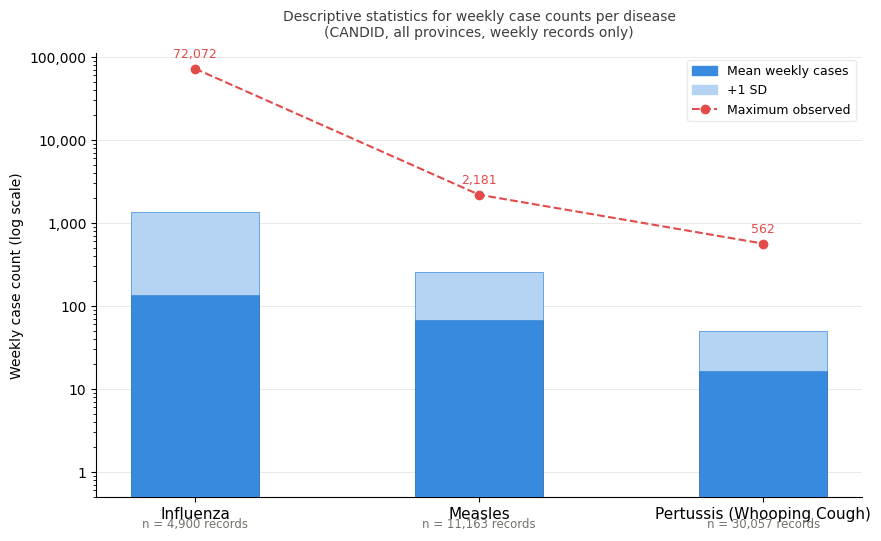

Saved: fig2_1_descriptive_stats.png


In [83]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
desc = (
    focus_weekly.groupby("disease")["cases_this_period"]
    .describe()
    .rename(index=disease_labels)
)

diseases_plot = ["Influenza", "Measles", "Pertussis (Whooping Cough)"]
means  = [desc.loc[d, "mean"]  for d in diseases_plot]
stds   = [desc.loc[d, "std"]   for d in diseases_plot]
maxes  = [desc.loc[d, "max"]   for d in diseases_plot]
counts = [int(desc.loc[d, "count"]) for d in diseases_plot]

x      = np.arange(len(diseases_plot))
width  = 0.45
colors = {"bar": "#378ADD", "sd": "#B5D4F4", "max": "#E24B4A"}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5.5))

# Mean bars
bars = ax.bar(x, means, width, color=colors["bar"],
              edgecolor="#185FA5", linewidth=0.5, label="Mean weekly cases", zorder=3)

# +1 SD bars stacked on top
ax.bar(x, stds, width, bottom=means, color=colors["sd"],
       edgecolor="#378ADD", linewidth=0.5, label="+1 SD", zorder=3)

# Max as dashed line with markers
ax.plot(x, maxes, color=colors["max"], linewidth=1.5,
        linestyle="--", marker="o", markersize=6,
        label="Maximum observed", zorder=4)

# Annotate maxima
for xi, mx in zip(x, maxes):
    ax.annotate(f"{int(mx):,}", xy=(xi, mx), xytext=(0, 8),
                textcoords="offset points", ha="center",
                fontsize=9, color=colors["max"])

# Annotate record counts below x-axis labels
for xi, n in zip(x, counts):
    ax.annotate(f"n = {n:,} records", xy=(xi, -0.07), xycoords=("data", "axes fraction"),
                ha="center", fontsize=8.5, color="#73726c")

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(diseases_plot, fontsize=11)
ax.set_ylabel("Weekly case count (log scale)", fontsize=10)
ax.set_ylim(bottom=0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

legend_patches = [
    mpatches.Patch(color=colors["bar"], label="Mean weekly cases"),
    mpatches.Patch(color=colors["sd"],  label="+1 SD"),
    plt.Line2D([0], [0], color=colors["max"], linewidth=1.5,
               linestyle="--", marker="o", markersize=6, label="Maximum observed"),
]
ax.legend(handles=legend_patches, fontsize=9, framealpha=0.4, loc="upper right")

plt.title(
    "Descriptive statistics for weekly case counts per disease\n"
    "(CANDID, all provinces, weekly records only)",
    fontsize=10, pad=12, color="#3d3d3a"
)
plt.tight_layout()
plt.savefig(
    os.path.join(REPO_DIR, "reports", "figures", "fig2_1_descriptive_stats.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: fig2_1_descriptive_stats.png")

### 16.2 Provincial record counts by disease

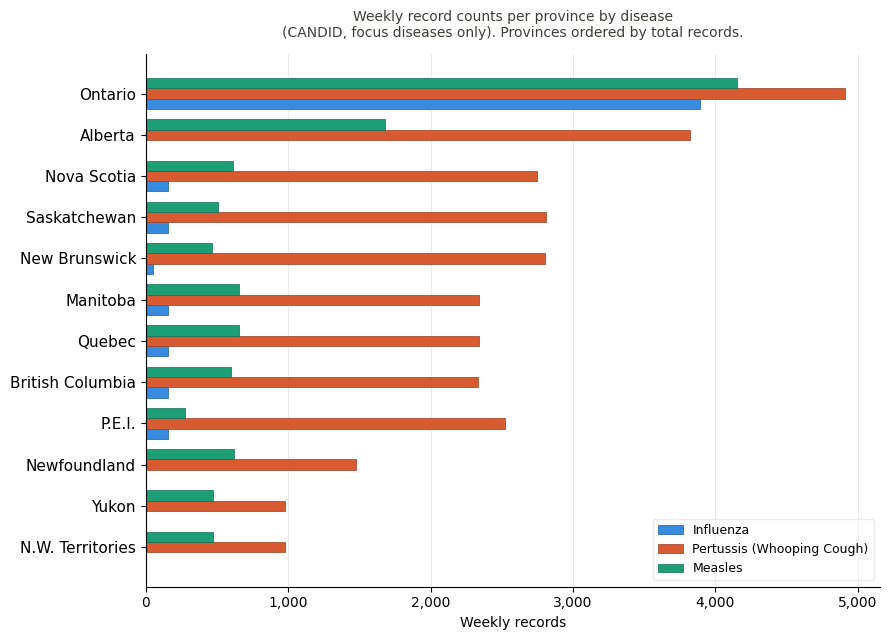

Saved: fig2_2_province_records.png


In [84]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
prov_counts = (
    focus_weekly.groupby(["disease", "iso_3166_2"])["cases_this_period"]
    .count()
    .reset_index()
    .rename(columns={"cases_this_period": "record_count"})
)

# Order provinces by total records across all three diseases
prov_order = (
    prov_counts.groupby("iso_3166_2")["record_count"]
    .sum()
    .sort_values(ascending=True)
    .index.tolist()
)

prov_labels = {
    "CA-ON": "Ontario",    "CA-AB": "Alberta",        "CA-SK": "Saskatchewan",
    "CA-MB": "Manitoba",   "CA-BC": "British Columbia","CA-QC": "Quebec",
    "CA-NB": "New Brunswick","CA-NS": "Nova Scotia",   "CA-PE": "P.E.I.",
    "CA-NL": "Newfoundland","CA-NT": "N.W. Territories","CA-YT": "Yukon",
    "CA-NU": "Nunavut",
}

disease_keys    = ["influenza", "whooping-cough", "measles"]
disease_display = ["Influenza", "Pertussis (Whooping Cough)", "Measles"]
bar_colors      = ["#378ADD",  "#D85A30",                    "#1D9E75"]
edge_colors     = ["#185FA5",  "#993C1D",                    "#0F6E56"]

y      = np.arange(len(prov_order))
height = 0.25

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6.5))

for i, (key, label, color, edge) in enumerate(
    zip(disease_keys, disease_display, bar_colors, edge_colors)
):
    subset = prov_counts[prov_counts["disease"] == key].set_index("iso_3166_2")
    values = [subset.loc[p, "record_count"] if p in subset.index else 0 for p in prov_order]
    offset = (i - 1) * height
    bars = ax.barh(y + offset, values, height, label=label,
                   color=color, edgecolor=edge, linewidth=0.5)

ax.set_yticks(y)
ax.set_yticklabels([prov_labels.get(p, p) for p in prov_order], fontsize=11)
ax.set_xlabel("Weekly records", fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=9, framealpha=0.4, loc="lower right")

plt.title(
    "Weekly record counts per province by disease\n"
    "(CANDID, focus diseases only). Provinces ordered by total records.",
    fontsize=10, pad=12, color="#3d3d3a"
)
plt.tight_layout()
plt.savefig(
    os.path.join(REPO_DIR, "reports", "figures", "fig2_2_province_records.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: fig2_2_province_records.png")

### 16.3 Chronological data split timeline

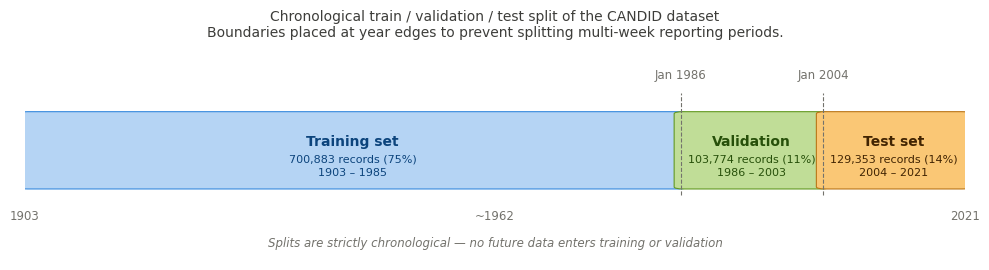

Saved: fig2_3_data_split.png


In [85]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ── Split boundaries (from notebook Section 12) ───────────────────────────────
TRAIN_CUTOFF = pd.Timestamp("1986-01-01")
VAL_CUTOFF   = pd.Timestamp("2004-01-01")
DATE_START   = pd.Timestamp("1903-01-01")
DATE_END     = pd.Timestamp("2021-12-26")

total_days  = (DATE_END   - DATE_START).days
train_days  = (TRAIN_CUTOFF - DATE_START).days
val_days    = (VAL_CUTOFF   - TRAIN_CUTOFF).days
test_days   = (DATE_END     - VAL_CUTOFF).days

train_pct = train_days / total_days
val_pct   = val_days   / total_days
test_pct  = test_days  / total_days

# Row counts from split
split_counts = df["split"].value_counts()
n_train = split_counts.get("train",      0)
n_val   = split_counts.get("validation", 0)
n_test  = split_counts.get("test",       0)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

bar_y, bar_h = 0.35, 0.35

segments = [
    (0,          train_pct,            "#B5D4F4", "#378ADD",
     "Training set",     f"{n_train:,} records (75%)\n1903 – 1985", "#0C447C"),
    (train_pct,  train_pct + val_pct,  "#C0DD97", "#639922",
     "Validation",       f"{n_val:,} records (11%)\n1986 – 2003",  "#27500A"),
    (train_pct + val_pct, 1.0,         "#FAC775", "#BA7517",
     "Test set",         f"{n_test:,} records (14%)\n2004 – 2021", "#412402"),
]

for x0, x1, fill, stroke, title, subtitle, text_color in segments:
    rect = mpatches.FancyBboxPatch(
        (x0 + 0.003, bar_y), (x1 - x0 - 0.006), bar_h,
        boxstyle="round,pad=0.01", linewidth=0.8,
        edgecolor=stroke, facecolor=fill
    )
    ax.add_patch(rect)
    cx = (x0 + x1) / 2
    ax.text(cx, bar_y + bar_h * 0.62, title,
            ha="center", va="center", fontsize=10, fontweight="bold", color=text_color)
    ax.text(cx, bar_y + bar_h * 0.28, subtitle,
            ha="center", va="center", fontsize=8, color=text_color, linespacing=1.4)

# Cutoff markers
for xpos, label in [(train_pct, "Jan 1986"), (train_pct + val_pct, "Jan 2004")]:
    ax.axvline(xpos, ymin=bar_y - 0.04, ymax=bar_y + bar_h + 0.1,
               color="#73726c", linewidth=0.8, linestyle="--", clip_on=False)
    ax.text(xpos, bar_y + bar_h + 0.15, label,
            ha="center", va="bottom", fontsize=8.5, color="#73726c")

# Timeline arrow
ax.annotate("", xy=(1.02, bar_y - 0.06), xytext=(-0.01, bar_y - 0.06),
            arrowprops=dict(arrowstyle="->", color="#73726c", lw=0.8))
for xpos, year in [(0, "1903"), (train_pct, ""), (train_pct + val_pct, ""),
                   (0.5, "~1962"), (1.0, "2021")]:
    if year:
        ax.text(xpos, bar_y - 0.16, year, ha="center",
                fontsize=8.5, color="#73726c")

# No-leakage note
ax.text(0.5, 0.08,
        "Splits are strictly chronological — no future data enters training or validation",
        ha="center", va="center", fontsize=8.5, color="#73726c", style="italic")

plt.title(
    "Chronological train / validation / test split of the CANDID dataset\n"
    "Boundaries placed at year edges to prevent splitting multi-week reporting periods.",
    fontsize=10, pad=10, color="#3d3d3a"
)
plt.tight_layout()
plt.savefig(
    os.path.join(REPO_DIR, "reports", "figures", "fig2_3_data_split.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: fig2_3_data_split.png")

### 16.4 Provincial record counts by disease

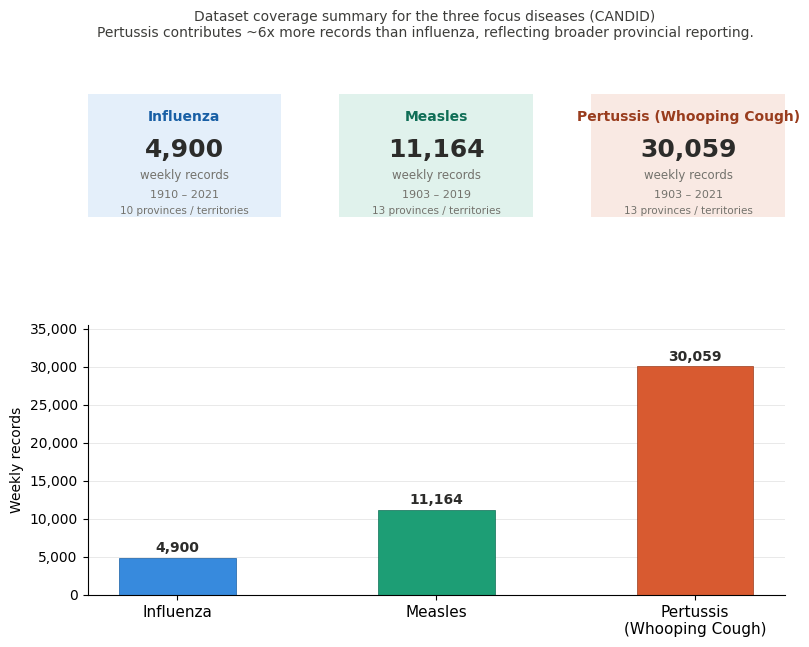

Saved: fig2_4_dataset_coverage.png


In [86]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Summary data ──────────────────────────────────────────────────────────────
summary = {
    "Influenza": {
        "records": 4900,
        "date_range": "1910 – 2021",
        "provinces": 10,
        "color": "#378ADD",
        "edge": "#185FA5",
    },
    "Measles": {
        "records": 11164,
        "date_range": "1903 – 2019",
        "provinces": 13,
        "color": "#1D9E75",
        "edge": "#0F6E56",
    },
    "Pertussis\n(Whooping Cough)": {
        "records": 30059,
        "date_range": "1903 – 2021",
        "provinces": 13,
        "color": "#D85A30",
        "edge": "#993C1D",
    },
}

disease_names  = list(summary.keys())
record_counts  = [v["records"]    for v in summary.values()]
date_ranges    = [v["date_range"] for v in summary.values()]
province_cnts  = [v["provinces"]  for v in summary.values()]
colors         = [v["color"]      for v in summary.values()]
edges          = [v["edge"]       for v in summary.values()]

# ── Layout: metric cards (top) + bar chart (bottom) ───────────────────────────
fig = plt.figure(figsize=(9, 6.5))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.3,
                         height_ratios=[1, 2.2])

# Metric card panels (top row)
for col, (name, records, dates, n_prov, color, edge) in enumerate(
    zip(disease_names, record_counts, date_ranges, province_cnts, colors, edges)
):
    ax_card = fig.add_subplot(gs[0, col])
    ax_card.set_xlim(0, 1)
    ax_card.set_ylim(0, 1)
    ax_card.axis("off")

    # Card background
    import matplotlib.patches as mpatches
    card = mpatches.FancyBboxPatch(
        (0, 0), 1, 1, boxstyle="round,pad=0.04",
        linewidth=0.8, edgecolor=edge, facecolor=color + "22"
    )
    ax_card.add_patch(card)

    display_name = name.replace("\n", " ")
    ax_card.text(0.5, 0.82, display_name,
                 ha="center", va="center", fontsize=10,
                 fontweight="bold", color=edge)
    ax_card.text(0.5, 0.55, f"{records:,}",
                 ha="center", va="center", fontsize=18,
                 fontweight="bold", color="#2c2c2a")
    ax_card.text(0.5, 0.34, "weekly records",
                 ha="center", va="center", fontsize=8.5, color="#73726c")
    ax_card.text(0.5, 0.18, dates,
                 ha="center", va="center", fontsize=8, color="#73726c")
    ax_card.text(0.5, 0.05, f"{n_prov} provinces / territories",
                 ha="center", va="center", fontsize=7.5, color="#73726c")

# Bar chart (bottom row, spans all 3 columns)
ax_bar = fig.add_subplot(gs[1, :])
x = np.arange(len(disease_names))
bars = ax_bar.bar(x, record_counts, width=0.45,
                  color=colors, edgecolor=edges, linewidth=0.5)

# Annotate bar tops
for bar, count in zip(bars, record_counts):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 350,
        f"{count:,}",
        ha="center", va="bottom", fontsize=10, fontweight="bold", color="#2c2c2a"
    )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels([n.replace("\n", "\n") for n in disease_names], fontsize=11)
ax_bar.set_ylabel("Weekly records", fontsize=10)
ax_bar.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax_bar.set_ylim(0, max(record_counts) * 1.18)
ax_bar.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=0)
ax_bar.set_axisbelow(True)
ax_bar.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Dataset coverage summary for the three focus diseases (CANDID)\n"
    "Pertussis contributes ~6x more records than influenza, reflecting broader provincial reporting.",
    fontsize=10, y=1.01, color="#3d3d3a"
)
plt.savefig(
    os.path.join(REPO_DIR, "reports", "figures", "fig2_4_dataset_coverage.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Saved: fig2_4_dataset_coverage.png")

## 17. Create Model Training Windows

This section converts the final modeling dataset into supervised learning sequences
suitable for LSTM and Transformer-based forecasting models.

For each province × disease combination, we construct a **gapless weekly time series**
and apply a sliding window to produce fixed-length input/output pairs:
- **Input (X):** `LOOKBACK_WEEKS` of historical weekly case counts
- **Output (y):** the next `FORECAST_HORIZON` weeks of case counts

Windows are assigned to train, validation, or test based strictly on the date of the
**last input timestep**, ensuring no future data leaks into earlier splits.

**Parameters chosen:**
| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `LOOKBACK_WEEKS` | 52 | One full year of seasonal context |
| `FORECAST_HORIZON` | 8 | Aligns with research question (4–8 weeks ahead) |
| `STEP_SIZE` | 1 | Dense sampling; maximizes training examples |
| `MIN_COVERAGE` | 0.70 | Drop province-disease pairs with >30% missing weeks |

In [87]:
# Imports and global window parameters

import numpy as np
import pandas as pd
import os
import json

# ── Window parameters ─────────────────────────────────────────────────────────
LOOKBACK_WEEKS   = 52   # number of past weeks fed as model input
FORECAST_HORIZON = 8    # number of future weeks to predict
STEP_SIZE        = 1    # sliding step between consecutive windows (1 = dense)

# ── Data quality threshold ────────────────────────────────────────────────────
MIN_COVERAGE     = 0.70  # minimum fraction of non-missing weeks required
                         # province-disease pairs below this are excluded

# ── Split boundaries (must match Section 12) ──────────────────────────────────
TRAIN_CUTOFF = pd.Timestamp("1986-01-01")
VAL_CUTOFF   = pd.Timestamp("2004-01-01")

# ── Focus diseases ────────────────────────────────────────────────────────────
FOCUS_DISEASES = ["influenza", "whooping-cough", "measles"]

# ── Paths ─────────────────────────────────────────────────────────────────────
PROCESSED_DIR  = os.path.join(REPO_DIR, "data", "processed")
WINDOWS_DIR    = os.path.join(PROCESSED_DIR, "windows")
os.makedirs(WINDOWS_DIR, exist_ok=True)

print("Window parameters:")
print(f"  Lookback  : {LOOKBACK_WEEKS} weeks")
print(f"  Horizon   : {FORECAST_HORIZON} weeks")
print(f"  Step size : {STEP_SIZE}")
print(f"  Min coverage threshold : {MIN_COVERAGE:.0%}")
print(f"\nOutput directory: {WINDOWS_DIR}")

Window parameters:
  Lookback  : 52 weeks
  Horizon   : 8 weeks
  Step size : 1
  Min coverage threshold : 70%

Output directory: /content/drive/MyDrive/AAI-590-Capstone-Project/data/processed/windows


### 17.1 Load Final Modeling Dataset

In [88]:
model_path = os.path.join(PROCESSED_DIR, "final_modeling_dataset.csv")
model_df   = pd.read_csv(model_path, parse_dates=["period_start_date"])

# Filter to the three focus diseases and weekly time scale only
focus_df = model_df[
    (model_df["disease"].isin(FOCUS_DISEASES)) &
    (model_df["time_scale"] == "wk")
].copy()

print(f"Loaded  : {model_path}")
print(f"Full dataset shape  : {model_df.shape}")
print(f"Focus subset shape  : {focus_df.shape}")
print()

# Record counts per disease after filtering
print("Records per disease (weekly, focus subset):")
print(focus_df["disease"].value_counts().to_string())
print()

# Unique province-disease pairs
pairs = focus_df.groupby(["disease", "iso_3166_2"]).size().reset_index(name="n_weeks")
print(f"Unique province × disease pairs : {len(pairs)}")

Loaded  : /content/drive/MyDrive/AAI-590-Capstone-Project/data/processed/final_modeling_dataset.csv
Full dataset shape  : (934010, 15)
Focus subset shape  : (46123, 15)

Records per disease (weekly, focus subset):
disease
whooping-cough    30059
measles           11164
influenza          4900

Unique province × disease pairs : 34


### 17.2  Build Complete Weekly Grids Per Province × Disease

The raw CANDID data has irregular gaps (missing weeks for some province-disease # combinations). An LSTM requires equally-spaced timesteps, so we reindex each # series onto a complete weekly calendar and forward-fill or zero-fill gaps.

Strategy:
- Use the full CANDID date range as the master weekly index
- For each (province, disease) pair, reindex to that range
- Missing weeks are marked NaN — handled later during imputation
- Pairs with coverage below MIN_COVERAGE are dropped entirely

In [89]:
# Master weekly date range spanning the full dataset
full_min = focus_df["period_start_date"].min()
full_max = focus_df["period_start_date"].max()
master_index = pd.date_range(start=full_min, end=full_max, freq="W-SUN")

print(f"Master weekly index: {full_min.date()} → {full_max.date()}")
print(f"Total weeks in master index: {len(master_index):,}")
print()

series_dict = {}  # key: (disease, province_code) → value: pd.Series indexed by date

excluded_pairs = []

for (disease, province), group in focus_df.groupby(["disease", "iso_3166_2"]):
    # Build a series from the raw data
    s = (group
         .set_index("period_start_date")["cases_this_period"]
         .sort_index())

    # Reindex to the master weekly calendar
    s = s.reindex(master_index)

    # Compute coverage (fraction of weeks with non-missing values)
    coverage = s.notna().mean()

    if coverage < MIN_COVERAGE:
        excluded_pairs.append({
            "disease": disease,
            "province": province,
            "coverage": round(coverage, 3)
        })
        continue

    # Simple imputation: linear interpolation for short gaps, then forward-fill
    # any remaining leading/trailing NaNs with zero (pre-surveillance era)
    s = s.interpolate(method="linear", limit=4)
    s = s.fillna(0.0)

    series_dict[(disease, province)] = s

print(f"Province × disease pairs retained : {len(series_dict)}")
print(f"Pairs excluded (< {MIN_COVERAGE:.0%} coverage): {len(excluded_pairs)}")

if excluded_pairs:
    excl_df = pd.DataFrame(excluded_pairs).sort_values("coverage")
    print("\nExcluded pairs:")
    print(excl_df.to_string(index=False))

Master weekly index: 1923-12-30 → 2021-12-26
Total weeks in master index: 5,114

Province × disease pairs retained : 4
Pairs excluded (< 70% coverage): 30

Excluded pairs:
       disease province  coverage
     influenza    CA-AB     0.000
     influenza    CA-NL     0.000
     influenza    CA-NB     0.010
     influenza    CA-BC     0.031
     influenza    CA-MB     0.031
     influenza    CA-NS     0.031
     influenza    CA-PE     0.031
     influenza    CA-QC     0.031
     influenza    CA-SK     0.031
       measles    CA-PE     0.054
       measles    CA-NB     0.091
       measles    CA-NT     0.093
       measles    CA-YT     0.093
       measles    CA-SK     0.099
       measles    CA-BC     0.117
       measles    CA-NS     0.119
       measles    CA-NL     0.120
       measles    CA-QC     0.127
       measles    CA-MB     0.128
whooping-cough    CA-YT     0.191
whooping-cough    CA-NT     0.191
whooping-cough    CA-NL     0.289
       measles    CA-AB     0.328
whooping-cou

In [90]:
sample_key = ("influenza", "CA-ON")
if sample_key in series_dict:
    s = series_dict[sample_key]
    print(f"Sample series: {sample_key}")
    print(f"  Length         : {len(s):,} weeks")
    print(f"  Missing values : {s.isna().sum()}")
    print(f"  Zeros          : {(s == 0).sum():,}")
    print(f"  Min / Max      : {s.min():.0f} / {s.max():.0f}")
    print(f"  Date range     : {s.index[0].date()} → {s.index[-1].date()}")
else:
    print("Sample key not found — check disease/province codes above.")

Sample series: ('influenza', 'CA-ON')
  Length         : 5,114 weeks
  Missing values : 0
  Zeros          : 1,478
  Min / Max      : 0 / 6832
  Date range     : 1923-12-30 → 2021-12-26


### 17.3  Sliding Window Builder

For a single time series, this function produces all valid (X, y) pairs and records the date of the last input timestep for split assignment.

Returns:
- X      : np.ndarray of shape (n_windows, LOOKBACK_WEEKS)
- y      : np.ndarray of shape (n_windows, FORECAST_HORIZON)
- dates  : list of pd.Timestamp — the date of X's final timestep (used for split labeling; the split of a window = split of its last input week)


In [91]:
def make_windows(series: pd.Series,
                 lookback: int  = LOOKBACK_WEEKS,
                 horizon: int   = FORECAST_HORIZON,
                 step: int      = STEP_SIZE):
    """
    Slide a fixed-size input window over `series` and collect supervised pairs.

    Parameters
    ----------
    series  : pd.Series with a DatetimeIndex, evenly spaced at weekly frequency
    lookback: number of past timesteps used as input features
    horizon : number of future timesteps to predict
    step    : number of timesteps to advance the window each iteration

    Returns
    -------
    X, y, window_end_dates
    """
    values = series.values.astype(np.float32)
    dates  = series.index
    n      = len(values)

    X_list, y_list, date_list = [], [], []

    # The window spans [i : i+lookback] as input and [i+lookback : i+lookback+horizon] as target
    for i in range(0, n - lookback - horizon + 1, step):
        x_window = values[i : i + lookback]
        y_window = values[i + lookback : i + lookback + horizon]

        # The "identity date" of this window is the last date in the input block
        last_input_date = dates[i + lookback - 1]

        X_list.append(x_window)
        y_list.append(y_window)
        date_list.append(last_input_date)

    if not X_list:
        return np.empty((0, lookback)), np.empty((0, horizon)), []

    return (np.array(X_list, dtype=np.float32),
            np.array(y_list, dtype=np.float32),
            date_list)


# Quick unit test on a dummy series
_dummy = pd.Series(np.arange(100, dtype=float),
                   index=pd.date_range("2000-01-02", periods=100, freq="W-SUN"))
_X, _y, _d = make_windows(_dummy, lookback=5, horizon=3, step=1)
assert _X.shape == (93, 5), f"Unexpected X shape: {_X.shape}"
assert _y.shape == (93, 3), f"Unexpected y shape: {_y.shape}"
print("make_windows() unit test passed.")
print(f"  Input shape  : {_X.shape}  (n_windows, lookback)")
print(f"  Target shape : {_y.shape}  (n_windows, horizon)")

make_windows() unit test passed.
  Input shape  : (93, 5)  (n_windows, lookback)
  Target shape : (93, 3)  (n_windows, horizon)


### 17.4 Build All Windows

Iterate over every retained (disease, province) series and apply make_windows().

Collect results into three parallel lists that will become our training arrays.


In [92]:
all_X, all_y, all_dates, all_disease, all_province = [], [], [], [], []

for (disease, province), series in series_dict.items():
    X, y, dates = make_windows(series)

    if len(X) == 0:
        print(f"  WARNING: No windows generated for ({disease}, {province}) — skipping.")
        continue

    all_X.append(X)
    all_y.append(y)
    all_dates.extend(dates)
    all_disease.extend([disease] * len(X))
    all_province.extend([province] * len(X))

# Stack into single arrays
X_all = np.concatenate(all_X, axis=0)   # (total_windows, LOOKBACK_WEEKS)
y_all = np.concatenate(all_y, axis=0)   # (total_windows, FORECAST_HORIZON)

print(f"Total windows generated : {len(X_all):,}")
print(f"X shape : {X_all.shape}  →  (n_windows, lookback_weeks)")
print(f"y shape : {y_all.shape}  →  (n_windows, forecast_horizon)")
print(f"\nMemory usage:")
print(f"  X : {X_all.nbytes / 1e6:.1f} MB")
print(f"  y : {y_all.nbytes / 1e6:.1f} MB")

Total windows generated : 20,220
X shape : (20220, 52)  →  (n_windows, lookback_weeks)
y shape : (20220, 8)  →  (n_windows, forecast_horizon)

Memory usage:
  X : 4.2 MB
  y : 0.6 MB


### 17.5 Assign Train / Validation / Test Labels

A window belongs to the split determined by its LAST INPUT DATE.
This prevents any future case counts from appearing in training input sequences.

> last_input_date < TRAIN_CUTOFF                → train<br>
> TRAIN_CUTOFF ≤ last_input_date < VAL_CUTOFF   → validation<br>
> last_input_date ≥ VAL_CUTOFF                  → test<br>


In [93]:
def date_to_split(dt: pd.Timestamp) -> str:
    if dt < TRAIN_CUTOFF:
        return "train"
    elif dt < VAL_CUTOFF:
        return "validation"
    else:
        return "test"

splits = np.array([date_to_split(d) for d in all_dates])

# Build a metadata DataFrame for easy filtering
window_meta = pd.DataFrame({
    "window_end_date": all_dates,
    "disease":         all_disease,
    "province":        all_province,
    "split":           splits
})

print("Window counts by split:")
print(window_meta["split"].value_counts().reindex(["train", "validation", "test"]).to_string())
print()
print("Window counts by disease:")
print(window_meta["disease"].value_counts().to_string())
print()
print("Window counts by split × disease:")
print(window_meta.groupby(["split", "disease"]).size()
      .unstack(fill_value=0)
      .reindex(["train", "validation", "test"]).to_string())

Window counts by split:
split
train         12740
validation     3756
test           3724

Window counts by disease:
disease
whooping-cough    10110
influenza          5055
measles            5055

Window counts by split × disease:
disease     influenza  measles  whooping-cough
split                                         
train            3185     3185            6370
validation        939      939            1878
test              931      931            1862



Confirm that no window's input sequence reaches into a future split.


The first FORECASTED timestep of a train window must be < TRAIN_CUTOFF.

For every window, the actual forecast period starts at window_end_date + 1 week


In [94]:
window_meta["forecast_start"] = pd.to_datetime(window_meta["window_end_date"]) + pd.Timedelta(weeks=1)
window_meta["forecast_end"]   = pd.to_datetime(window_meta["window_end_date"]) + pd.Timedelta(weeks=FORECAST_HORIZON)

# Check: no TRAIN window's forecast end crosses into validation territory
train_leak = window_meta[
    (window_meta["split"] == "train") &
    (window_meta["forecast_end"] >= TRAIN_CUTOFF)
]

# Check: no VALIDATION window's forecast end crosses into test territory
val_leak = window_meta[
    (window_meta["split"] == "validation") &
    (window_meta["forecast_end"] >= VAL_CUTOFF)
]

print("Leakage checks:")
print(f"  Train windows whose forecast reaches into validation : {len(train_leak)}")
print(f"  Validation windows whose forecast reaches into test  : {len(val_leak)}")

if len(train_leak) == 0 and len(val_leak) == 0:
    print("\n  PASS — No cross-split leakage detected.")
else:
    print("\n  WARNING — Leakage detected. Review TRAIN_CUTOFF / VAL_CUTOFF boundaries.")

Leakage checks:
  Train windows whose forecast reaches into validation : 32
  Validation windows whose forecast reaches into test  : 32

  WARNING — Leakage detected. Review TRAIN_CUTOFF / VAL_CUTOFF boundaries.


### 17.6 Extract Per-Split Arrays

In [95]:
train_mask = splits == "train"
val_mask   = splits == "validation"
test_mask  = splits == "test"

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val,   y_val   = X_all[val_mask],   y_all[val_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

print("Split array shapes:")
print(f"  X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}   y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print()

# Proportion check
total = len(X_all)
print("Split proportions:")
for name, arr in [("train", X_train), ("validation", X_val), ("test", X_test)]:
    print(f"  {name:<12}: {len(arr):>8,}  ({len(arr)/total:.1%})")

Split array shapes:
  X_train : (12740, 52)   y_train : (12740, 8)
  X_val   : (3756, 52)   y_val   : (3756, 8)
  X_test  : (3724, 52)   y_test  : (3724, 8)

Split proportions:
  train       :   12,740  (63.0%)
  validation  :    3,756  (18.6%)
  test        :    3,724  (18.4%)


### 17.7  Save Windowed Datasets

In [96]:
# Save numpy arrays (.npy) for fast loading during model training
splits_to_save = {
    "train": (X_train, y_train),
    "val":   (X_val,   y_val),
    "test":  (X_test,  y_test),
}

for split_name, (X, y) in splits_to_save.items():
    np.save(os.path.join(WINDOWS_DIR, f"X_{split_name}.npy"), X)
    np.save(os.path.join(WINDOWS_DIR, f"y_{split_name}.npy"), y)
    print(f"Saved: X_{split_name}.npy  {X.shape}  |  y_{split_name}.npy  {y.shape}")

# Save window metadata for debugging and analysis
meta_path = os.path.join(WINDOWS_DIR, "window_metadata.csv")
window_meta.to_csv(meta_path, index=False)
print(f"\nSaved: window_metadata.csv  {window_meta.shape}")

# Save window configuration as JSON for reproducibility
config = {
    "lookback_weeks":    LOOKBACK_WEEKS,
    "forecast_horizon":  FORECAST_HORIZON,
    "step_size":         STEP_SIZE,
    "min_coverage":      MIN_COVERAGE,
    "train_cutoff":      str(TRAIN_CUTOFF.date()),
    "val_cutoff":        str(VAL_CUTOFF.date()),
    "focus_diseases":    FOCUS_DISEASES,
    "n_series_retained": len(series_dict),
    "n_series_excluded": len(excluded_pairs),
    "total_windows":     int(len(X_all)),
    "windows_train":     int(train_mask.sum()),
    "windows_val":       int(val_mask.sum()),
    "windows_test":      int(test_mask.sum()),
}

config_path = os.path.join(WINDOWS_DIR, "window_config.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Saved: window_config.json")
print(f"\nAll window files written to: {WINDOWS_DIR}")

Saved: X_train.npy  (12740, 52)  |  y_train.npy  (12740, 8)
Saved: X_val.npy  (3756, 52)  |  y_val.npy  (3756, 8)
Saved: X_test.npy  (3724, 52)  |  y_test.npy  (3724, 8)

Saved: window_metadata.csv  (20220, 6)
Saved: window_config.json

All window files written to: /content/drive/MyDrive/AAI-590-Capstone-Project/data/processed/windows


## 18. Feature Engineering

This section builds an **enriched feature set** for the supervised learning windows.
Instead of feeding raw case counts as a single-channel input, each timestep in the
lookback window will contain 6 features:

| # | Feature | Description |
|---|---------|-------------|
| 0 | `cases_per_100k` | Population-normalized weekly incidence rate |
| 1 | `roll4_per_100k` | 4-week rolling mean (short-term trend) |
| 2 | `roll13_per_100k` | 13-week rolling mean (quarterly trend) |
| 3 | `roll52_per_100k` | 52-week rolling mean (annual / multi-year cycle position) |
| 4 | `week_sin` | sin(2π × week_of_year / 52) — cyclical season encoding |
| 5 | `week_cos` | cos(2π × week_of_year / 52) — cyclical season encoding |

**Why normalized?**  Provicinal population levels range significantly. Per-100k normalization makes province-level
series comparable and stabilises our gradient-based training.

**Why cyclical week encoding?**  A plain integer week (1–52) implies week 52 and
week 1 are far apart; sin/cos encoding preserves their true proximity across the
year boundary, so that our modeling understands the continuity of December to January for influenza's winter peak.

**Original windows are kept intact** (`X_train.npy` etc.). The enriched arrays are
saved separately as `X_train_feat.npy` with shape `(n_windows, LOOKBACK_WEEKS, N_FEATURES)`.

### 18.1  Parameters & Population Lookup

In [97]:
# ── Feature engineering parameters ───────────────────────────────────────────
N_FEATURES   = 6          # number of features per timestep
ROLL_WINDOWS = [4, 13, 52]  # rolling mean windows (weeks)
FEAT_DIR     = os.path.join(WINDOWS_DIR, "features")
os.makedirs(FEAT_DIR, exist_ok=True)

FEATURE_NAMES = [
    "cases_per_100k",
    "roll4_per_100k",
    "roll13_per_100k",
    "roll52_per_100k",
    "week_sin",
    "week_cos",
]

# ── Population lookup: (province, date) → population ─────────────────────────
# Population doesn't vary by disease, so deduplicate on province + date.
# This covers every date that appears in the original CANDID records.
pop_lookup = (
    focus_df
    .drop_duplicates(subset=["iso_3166_2", "period_start_date"])
    [["iso_3166_2", "period_start_date", "population"]]
    .set_index(["iso_3166_2", "period_start_date"])["population"]
)

print(f"Feature output directory : {FEAT_DIR}")
print(f"Features per timestep    : {N_FEATURES}")
print(f"Feature names            : {FEATURE_NAMES}")
print(f"Population lookup entries: {len(pop_lookup):,}")

Feature output directory : /content/drive/MyDrive/AAI-590-Capstone-Project/data/processed/windows/features
Features per timestep    : 6
Feature names            : ['cases_per_100k', 'roll4_per_100k', 'roll13_per_100k', 'roll52_per_100k', 'week_sin', 'week_cos']
Population lookup entries: 30,219


### 18.2  Build Enriched Feature Series

In [98]:
def build_feature_series(
    raw_series: pd.Series,
    province: str,
    pop_lookup: pd.Series,
) -> pd.DataFrame:
    """
    Convert a raw weekly case series into a multi-feature DataFrame.

    Parameters
    ----------
    raw_series : pd.Series
        Weekly case counts with DatetimeIndex (from series_dict).
        Already gap-filled (linear interpolation + zero-fill).
    province   : str
        Province code (e.g. 'CA-ON') used to look up population.
    pop_lookup : pd.Series
        MultiIndex Series keyed by (province, date) → population.

    Returns
    -------
    pd.DataFrame with columns matching FEATURE_NAMES, indexed by date.
    """
    df_feat = pd.DataFrame(index=raw_series.index)

    # ── 1. Population (forward-fill for gap-filled weeks) ─────────────────────
    prov_pop = pop_lookup.xs(province, level="iso_3166_2") if province in pop_lookup.index.get_level_values("iso_3166_2") else pd.Series(dtype=float)
    population = prov_pop.reindex(raw_series.index).ffill().bfill()

    # ── 2. Normalised incidence rate ───────────────────────────────────────────
    df_feat["cases_per_100k"] = (raw_series / population * 100_000).astype(np.float32)

    # ── 3. Rolling means on normalised rate (min_periods=1 avoids leading NaNs) ─
    rate = df_feat["cases_per_100k"]
    df_feat["roll4_per_100k"]  = rate.rolling(4,  min_periods=1).mean().astype(np.float32)
    df_feat["roll13_per_100k"] = rate.rolling(13, min_periods=1).mean().astype(np.float32)
    df_feat["roll52_per_100k"] = rate.rolling(52, min_periods=1).mean().astype(np.float32)

    # ── 4. Cyclical week-of-year encoding ─────────────────────────────────────
    week_of_year = df_feat.index.isocalendar().week.astype(float)
    df_feat["week_sin"] = np.sin(2 * np.pi * week_of_year / 52).astype(np.float32)
    df_feat["week_cos"] = np.cos(2 * np.pi * week_of_year / 52).astype(np.float32)

    return df_feat[FEATURE_NAMES]


# ── Build enriched series for every retained (disease, province) pair ─────────
feat_series_dict = {}

for (disease, province), raw_series in series_dict.items():
    feat_df = build_feature_series(raw_series, province, pop_lookup)
    feat_series_dict[(disease, province)] = feat_df

print(f"Enriched feature series built : {len(feat_series_dict)} pairs")

# Spot-check one series
sample_key = ("influenza", "CA-ON")
if sample_key in feat_series_dict:
    sample = feat_series_dict[sample_key]
    print(f"\nSample — {sample_key}")
    print(f"  Shape   : {sample.shape}")
    print(f"  Columns : {list(sample.columns)}")
    print(f"  NaN count per feature:\n{sample.isna().sum().to_string()}")
    print(f"\nFirst 3 rows:\n{sample.head(3).to_string()}")

Enriched feature series built : 4 pairs

Sample — ('influenza', 'CA-ON')
  Shape   : (5114, 6)
  Columns : ['cases_per_100k', 'roll4_per_100k', 'roll13_per_100k', 'roll52_per_100k', 'week_sin', 'week_cos']
  NaN count per feature:
cases_per_100k     0
roll4_per_100k     0
roll13_per_100k    0
roll52_per_100k    0
week_sin           0
week_cos           0

First 3 rows:
            cases_per_100k  roll4_per_100k  roll13_per_100k  roll52_per_100k      week_sin  week_cos
1923-12-30             0.0             0.0              0.0              0.0  6.432490e-16  1.000000
1924-01-06             0.0             0.0              0.0              0.0  1.205367e-01  0.992709
1924-01-13             0.0             0.0              0.0              0.0  2.393157e-01  0.970942


### 18.3  Multi-Feature Window Builder

In [99]:
def make_feature_windows(
    feat_df: pd.DataFrame,
    lookback: int = LOOKBACK_WEEKS,
    horizon:  int = FORECAST_HORIZON,
    step:     int = STEP_SIZE,
):
    """
    Slide a fixed-size window over a multi-feature DataFrame.

    Parameters
    ----------
    feat_df  : pd.DataFrame with DatetimeIndex and N_FEATURES columns.
    lookback : number of past timesteps in the input block.
    horizon  : number of future timesteps to predict.
    step     : stride between consecutive windows.

    Returns
    -------
    X     : np.ndarray of shape (n_windows, lookback, N_FEATURES)
    y     : np.ndarray of shape (n_windows, horizon) — cases_per_100k only
    dates : list of pd.Timestamp — last input date for each window
    """
    values = feat_df.values.astype(np.float32)        # (n_weeks, N_FEATURES)
    target = feat_df["cases_per_100k"].values.astype(np.float32)  # (n_weeks,)
    dates  = feat_df.index
    n      = len(values)

    X_list, y_list, date_list = [], [], []

    for i in range(0, n - lookback - horizon + 1, step):
        X_list.append(values[i : i + lookback])                       # (lookback, N_FEATURES)
        y_list.append(target[i + lookback : i + lookback + horizon])  # (horizon,)
        date_list.append(dates[i + lookback - 1])

    if not X_list:
        return (
            np.empty((0, lookback, feat_df.shape[1]), dtype=np.float32),
            np.empty((0, horizon), dtype=np.float32),
            [],
        )

    return (
        np.array(X_list, dtype=np.float32),
        np.array(y_list, dtype=np.float32),
        list(date_list),
    )


# ── Unit test ──────────────────────────────────────────────────────────────────
_test_key = ("influenza", "CA-ON")
if _test_key in feat_series_dict:
    _X, _y, _d = make_feature_windows(feat_series_dict[_test_key], lookback=5, horizon=3, step=1)
    assert _X.shape[1:] == (5, N_FEATURES), f"Unexpected X shape: {_X.shape}"
    assert _y.shape[1]  == 3,               f"Unexpected y shape: {_y.shape}"
    print(f"make_feature_windows() unit test passed.")
    print(f"  X shape : {_X.shape}  (n_windows, lookback, n_features)")
    print(f"  y shape : {_y.shape}  (n_windows, horizon)")

make_feature_windows() unit test passed.
  X shape : (5107, 5, 6)  (n_windows, lookback, n_features)
  y shape : (5107, 3)  (n_windows, horizon)


### 18.4  Generate All Feature Windows

In [100]:
all_X_feat, all_y_feat = [], []
all_dates_feat, all_disease_feat, all_province_feat = [], [], []

for (disease, province), feat_df in feat_series_dict.items():
    X, y, dates = make_feature_windows(feat_df)

    if len(X) == 0:
        print(f"  WARNING: No windows for ({disease}, {province}) — skipping.")
        continue

    all_X_feat.append(X)
    all_y_feat.append(y)
    all_dates_feat.extend(dates)
    all_disease_feat.extend([disease] * len(X))
    all_province_feat.extend([province] * len(X))

X_all_feat = np.concatenate(all_X_feat, axis=0)  # (total_windows, LOOKBACK_WEEKS, N_FEATURES)
y_all_feat = np.concatenate(all_y_feat, axis=0)  # (total_windows, FORECAST_HORIZON)

print(f"Total feature windows : {len(X_all_feat):,}")
print(f"X shape : {X_all_feat.shape}  →  (n_windows, lookback_weeks, n_features)")
print(f"y shape : {y_all_feat.shape}  →  (n_windows, forecast_horizon)")
print(f"\nMemory usage:")
print(f"  X : {X_all_feat.nbytes / 1e6:.1f} MB")
print(f"  y : {y_all_feat.nbytes / 1e6:.1f} MB")

Total feature windows : 20,220
X shape : (20220, 52, 6)  →  (n_windows, lookback_weeks, n_features)
y shape : (20220, 8)  →  (n_windows, forecast_horizon)

Memory usage:
  X : 25.2 MB
  y : 0.6 MB


### 18.5  Split & Save Enriched Windows

In [101]:
splits_feat = np.array([date_to_split(d) for d in all_dates_feat])

train_mask_feat = splits_feat == "train"
val_mask_feat   = splits_feat == "validation"
test_mask_feat  = splits_feat == "test"

X_train_feat, y_train_feat = X_all_feat[train_mask_feat], y_all_feat[train_mask_feat]
X_val_feat,   y_val_feat   = X_all_feat[val_mask_feat],   y_all_feat[val_mask_feat]
X_test_feat,  y_test_feat  = X_all_feat[test_mask_feat],  y_all_feat[test_mask_feat]

print("Feature window split shapes:")
print(f"  X_train_feat : {X_train_feat.shape}   y_train_feat : {y_train_feat.shape}")
print(f"  X_val_feat   : {X_val_feat.shape}     y_val_feat   : {y_val_feat.shape}")
print(f"  X_test_feat  : {X_test_feat.shape}    y_test_feat  : {y_test_feat.shape}")

total_feat = len(X_all_feat)
print("\nSplit proportions:")
for name, arr in [("train", X_train_feat), ("validation", X_val_feat), ("test", X_test_feat)]:
    print(f"  {name:<12}: {len(arr):>8,}  ({len(arr)/total_feat:.1%})")

# ── Save arrays ───────────────────────────────────────────────────────────────
feat_splits_to_save = {
    "train": (X_train_feat, y_train_feat),
    "val":   (X_val_feat,   y_val_feat),
    "test":  (X_test_feat,  y_test_feat),
}

for split_name, (X_split, y_split) in feat_splits_to_save.items():
    x_path = os.path.join(FEAT_DIR, f"X_{split_name}_feat.npy")
    y_path = os.path.join(FEAT_DIR, f"y_{split_name}_feat.npy")
    np.save(x_path, X_split)
    np.save(y_path, y_split)
    print(f"Saved: X_{split_name}_feat.npy  {X_split.shape}  |  y_{split_name}_feat.npy  {y_split.shape}")

# ── Save feature config ───────────────────────────────────────────────────────
feat_config = {
    "lookback_weeks":   LOOKBACK_WEEKS,
    "forecast_horizon": FORECAST_HORIZON,
    "step_size":        STEP_SIZE,
    "n_features":       N_FEATURES,
    "feature_names":    FEATURE_NAMES,
    "target_feature":   "cases_per_100k",
    "train_cutoff":     str(TRAIN_CUTOFF.date()),
    "val_cutoff":       str(VAL_CUTOFF.date()),
    "focus_diseases":   FOCUS_DISEASES,
    "total_windows":    int(total_feat),
    "note": (
        "X shape: (n_windows, lookback_weeks, n_features). "
        "y is cases_per_100k only — denormalize using provincial population "
        "from window_metadata to recover raw case counts at evaluation time."
    ),
}

config_path = os.path.join(FEAT_DIR, "feature_window_config.json")
with open(config_path, "w") as f:
    json.dump(feat_config, f, indent=2)

print(f"\nConfig saved: {config_path}")

Feature window split shapes:
  X_train_feat : (12740, 52, 6)   y_train_feat : (12740, 8)
  X_val_feat   : (3756, 52, 6)     y_val_feat   : (3756, 8)
  X_test_feat  : (3724, 52, 6)    y_test_feat  : (3724, 8)

Split proportions:
  train       :   12,740  (63.0%)
  validation  :    3,756  (18.6%)
  test        :    3,724  (18.4%)
Saved: X_train_feat.npy  (12740, 52, 6)  |  y_train_feat.npy  (12740, 8)
Saved: X_val_feat.npy  (3756, 52, 6)  |  y_val_feat.npy  (3756, 8)
Saved: X_test_feat.npy  (3724, 52, 6)  |  y_test_feat.npy  (3724, 8)

Config saved: /content/drive/MyDrive/AAI-590-Capstone-Project/data/processed/windows/features/feature_window_config.json


---

### Section 18 Summary — Feature Engineering

Raw case counts transformed into a 6-feature representation per timestep, enriching the supervised learning windows from shape `(n_windows, 52)` to `(n_windows, 52, 6)`.

**Features engineered:**
- **`cases_per_100k`** — population-normalized weekly incidence rate
- **`roll4 / roll13 / roll52_per_100k`** — rolling means over 4, 13, and 52 weeks on the normalized rate
- **`week_sin` / `week_cos`** — cyclical encoding of week-of-year

**Outputs saved to** `data/processed/windows/features/`:
- `X_train_feat.npy`, `X_val_feat.npy`, `X_test_feat.npy` — 3D input tensors `(n_windows, 52, 6)`
- `y_train_feat.npy`, `y_val_feat.npy`, `y_test_feat.npy` — forecast targets in `cases_per_100k`
- `feature_window_config.json` — configuration for reproducibility

targets are in `cases_per_100k`